# Chicago Crime

**Author:** Erik Pak 
**Date:** 04/2026 
**Data:** Chicago Data Portal - Crime Incidents 2001-2025


https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data

https://data.cityofchicago.org/Public-Safety/Chicago-Police-Department-Illinois-Uniform-Crime-R/c7ck-438e/about_data

___
## Scope:
We are modeling crime incidence as a multivariate, non-stationary stochastic process and detecting shifts in crime types via structural break detection in latent distributional parameters across the pre-COVID, COVID, and post-COVID periods.

## Era Definitions

| Era    | Period         | Months |
|------------|-------------------------|--------|
| Pre-COVID | Jan 2001 - Feb 2020   | 230  |
| COVID   | Mar 2020 - Dec 2022   | 34   |
| Post-COVID | Jan 2023 - April 2026   | 40   |

Era cutoff rationale: The COVID era begins in March 2020, coinciding with the Illinois stay-at-home order (March 21, 2020) and the WHO pandemic declaration (March 11, 2020). The post-COVID era begins in January 2023, following the expiration of Illinois's disaster proclamation and the effective end of major federal pandemic-era policies in late 2022. These boundaries are administrative and policy-based; the underlying behavioral and enforcement shifts may not align exactly with these dates.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import ruptures as rpt

# Path + custom modules---
sys.path.append('../Src/') 
import clr_config as cfg
import clr_utilities as utils
import clr_eps_grid as grid
import clr_analyze_plot as plot
import clr_era as clr
import clr_pca_sign_normalization as pca_anchor

# Image Path
image_path = "../Image/"

# Seed
_RANDOM_STATE = 1776

# Library versions
versions = {
  "Python" : sys.version.split()[0],
  "Pandas" : pd.__version__,
  "NumPy"  : np.__version__,
  "Pyarrow" : pa.__version__,
  "Seaborn" : sns.__version__,
  "Matplot" : sys.modules['matplotlib'].__version__,
  "Ruptures": sys.modules['ruptures'].__version__,
  "Scipy"  : sys.modules['scipy'].__version__,
}
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=6, linewidth=100)

    Library  Version
0    Python   3.13.9
1    Pandas    2.3.3
2     NumPy    2.3.4
3   Pyarrow   22.0.0
4   Seaborn   0.13.2
5   Matplot   3.10.7
6  Ruptures  v1.1.10
7     Scipy   1.16.3


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_description,secondary_description,index_code,primary_type,description,location_description,...,y_coordinate,era,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location
8265318,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSSESS - CANNABIS 30 GRAMS OR LESS,N,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,...,1857566,pre_covid,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing
7080787,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,I,THEFT,FROM BUILDING,APARTMENT,...,1854276,pre_covid,July,Saturday,Q3,2003-Q3,Evening,Larceny - Theft,True,Gresham
6396203,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSSESS - HEROIN (WHITE),N,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,...,1903996,pre_covid,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison
5818733,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,I,BURGLARY,FORCIBLE ENTRY,APARTMENT,...,1916864,pre_covid,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central
5312174,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,N,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,...,1914371,pre_covid,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central


## Data Integration & Cleaning

In [3]:
# New column
df['year_month'] = df['date'].dt.strftime('%Y%m')
# Normalize era keys to consistent labels
df['era'] = df['era'].map(cfg.era_map).fillna(df.era)
# display
df.era.unique()

array(['Pre-COVID', 'Post-COVID', 'COVID'], dtype=object)

In [4]:
# get the dates of period in the dataset
start_date = pd.to_datetime(df[cfg.config_agg["_DATE_KEY"]].min(), format='%Y%m').date().strftime('%Y-%m')
end_date = pd.to_datetime(df[cfg.config_agg["_DATE_KEY"]].max(), format='%Y%m').date().strftime('%Y-%m') 
# print the date range
print(f"Dataset covers from {start_date} to {end_date}")

Dataset covers from 2001-01 to 2026-04


### Check missingness

In [5]:
# Check integrity and missingness
missingness_results = utils.run_integrity_report(df)


--------------------------------------------------
 📑  PANEL INTEGRITY & SPARSITY DIAGNOSTIC
--------------------------------------------------
  • Date Horizon   : 2001-01 to 2026-04
  • Total Months   : 304
  • Feature Space  : 32 crime categories
  • Total Panel    : 9,728 (expected combinations)
  • Actual Density : 8,392 (observed rows)
--------------------------------------------------
  🚨 Completeness  : 86.27%
  🔍 Missing Gaps  : 1,336 rows
  👯 Duplicates    : 0 rows
--------------------------------------------------

 🔥  CRITICAL: TRUE MISSING GAPS
    (These months are entirely absent from the raw data)
    ↳ RITUALISM                                      |  286 months missing
    ↳ NON-CRIMINAL                                   |  281 months missing
    ↳ HUMAN TRAFFICKING                              |  214 months missing
    ↳ OTHER NARCOTIC VIOLATION                       |  190 months missing
    ↳ CONCEALED CARRY LICENSE VIOLATION              |  160 months missing
   

#### 📌 Summary
> When we sorted every crime category by how often it appeared across the months in the panel, the distribution split into two clear groups, with a wide gap between them. On the high end are 26 categories that appear in 90% or more of months, most of which are present in nearly every month. At the low end are 6 categories that appear in 52% or fewer of the months. Between 52.3% and 90.5%, there are no categories, leaving a 38-point gap in the distribution. We did not choose the 90% cutoff because it is a round number or an arbitrary threshold, but because it aligns with this natural separation in the data. Any cutoff between 52% and 90% would produce the same two-group structure. We selected 90% because it lies at the boundary of the high-coverage cluster and provides a simple, interpretable rule: a category is considered dense if it appears in at least 90% of its available months. To assess robustness, we re-run the analysis at a stricter cutoff of 0.95, which reclassifies the two borderline-dense categories (Obscenity and Gambling, both at 90.5%).

#### User Function(s)

In [6]:
def pca_prep_comparison(
    epsilon_sweep_result: dict,
    epsilon: float,
    epsilon_alt: float
):

    # Build comparison list
    eps_list = [epsilon, epsilon_alt]

    # Storage for results
    results_pca = {}

    # Loop over epsilons and generate plots
    for eps in eps_list:
        clr_df = epsilon_sweep_result["clr_dict"][eps]

        result = pca_anchor.compute_pca(
            clr_df,
            epsilon=eps,
            verbose=False,
        )

        results_pca[eps] = result

    return results_pca



def check_clr_health(sweep_result, target_eps=None):
    """
    Validates the numerical structure and CLR zero‑sum health for a specific epsilon.

    Args:
        sweep_result (dict): Output from sweep_epsilon_grid(...).
        target_eps (float, optional): Epsilon to inspect. Defaults to chosen_eps.

    Returns:
        dict: The full clr_dict (unchanged), or None if epsilon is missing.
    """

    # Default to auto‑chosen epsilon
    if target_eps is None:
        target_eps = sweep_result['meta']['chosen_eps']

    clr_dict = sweep_result.get('clr_dict', {})

    # Validate epsilon exists
    if target_eps not in clr_dict:
        print(f"⚠️ Warning: Epsilon {target_eps:.10f} not found in clr_dict.")
        return None

    # Extract the CLR dataframe
    target_df = clr_dict[target_eps]
    rows, cols = target_df.shape

    # Temporal range formatting
    start_dt = target_df.index[0].strftime('%Y-%m')
    end_dt   = target_df.index[-1].strftime('%Y-%m')

    # CLR zero‑sum health check
    mean_abs_sum = target_df.sum(axis=1).abs().mean()
    health_status = "🟢 OPTIMAL" if mean_abs_sum < 1e-12 else "🔴 RE‑CENTERING REQUIRED"

    # Output summary
    print(f"{' ERA STRUCTURE ':=^50}")
    print(f"Container Type    : {type(clr_dict).__name__}")
    print(f"Total Categories  : {cols}")

    print(f"\n{' TARGET EPSILON: ' + f'{target_eps:.10f}':-^50}")
    print(f"Dimensions        : {rows} months x {cols} categories")
    print(f"Temporal Range    : {start_dt} to {end_dt}")
    print(f"Primary Features  : {', '.join(target_df.columns[:3])} ...")
    print(f"Numerical Health  : {mean_abs_sum:.2e} ({health_status})")
    print(f"{'':=^50}")

    return clr_dict

In [7]:
# Extract the support-frequency Series for primary_description
coverage = missingness_results['coverage_ratio']

# Select all categories that appear in < 70% of months (Sparse Layer)
sparse = coverage[coverage < 0.90].index.tolist()

# Select all categories that appear in ≥ 70% of months (Dense Layer)
dense  = coverage[coverage >= 0.90].index.tolist()

# Filter the original DataFrame by matching primary_description values
df_sparse = df[df[cfg.config_agg['_GROUP_KEY']].isin(sparse)].copy()
df_dense  = df[df[cfg.config_agg['_GROUP_KEY']].isin(dense)].copy()

### Sparse

In [8]:
# Check integrity and missingness
missingness_sparse = utils.run_integrity_report(df_sparse)


--------------------------------------------------
 📑  PANEL INTEGRITY & SPARSITY DIAGNOSTIC
--------------------------------------------------
  • Date Horizon   : 2001-01 to 2026-04
  • Total Months   : 304
  • Feature Space  : 6 crime categories
  • Total Panel    : 1,824 (expected combinations)
  • Actual Density : 548 (observed rows)
--------------------------------------------------
  🚨 Completeness  : 30.04%
  🔍 Missing Gaps  : 1,276 rows
  👯 Duplicates    : 0 rows
--------------------------------------------------

 🔥  CRITICAL: TRUE MISSING GAPS
    (These months are entirely absent from the raw data)
    ↳ RITUALISM                                      |  286 months missing
    ↳ NON-CRIMINAL                                   |  281 months missing
    ↳ HUMAN TRAFFICKING                              |  214 months missing
    ↳ OTHER NARCOTIC VIOLATION                       |  190 months missing
    ↳ CONCEALED CARRY LICENSE VIOLATION              |  160 months missing
    ↳ 

In [9]:
# Fill missing data and report
fill_results_sparse = utils.fill_missing(df_sparse)


 🧩  CRIME DATA FILLING & PANEL ALIGNMENT
  • Date Range                     : 2001-01 to 2026-04
  • Total Groups                   : 6
  • Total Periods                  : 304
------------------------------------------------------------------
  📦 Final Panel Size               : 1,824 rows
  🩹 Filled Gaps                    : 1,276 rows
  🔢 Fill Value Used                : 0
------------------------------------------------------------------
 ✅ Audit flags: 'was_missing', 'is_zero_after_fill'



In [10]:
# Validate filled data
utils.validate_crime_data(fill_results_sparse['filled_df'], zero_rate_threshold = 0.7)


                   🛡️  CRIME DATA STRUCTURAL INTEGRITY CHECK                    
  ✅ Date Dtype                 : PASS | datetime64 required
  ✅ Global Sort                : PASS | Group-Date ordering
  ✅ Temporal Continuity        : PASS | Linear timeline
  ✅ Period Sync                : PASS | All groups have 304 months
  ✅ Value Range                : PASS | 0 negative values
  ✅ NaN Cleanup                : PASS | 0 missing entries
  ✅ Record Uniqueness          : PASS | 0 duplicates
  ✅ Audit: was_missing         : PASS | Traceability
  ✅ Audit: is_zero_after_fill  : PASS | Traceability
--------------------------------------------------------------------------------
  🔍 Overall Zero Rate          : INFO | 69.96%

 🧪  SPARSITY EXPOSURE BY CATEGORY
    (Threshold: > 70% zeros)
    ↳ RITUALISM                                          |   94.1% zero rate
    ↳ NON-CRIMINAL                                       |   92.4% zero rate
    ↳ HUMAN TRAFFICKING                               

### Dense

In [11]:
# Check integrity and missingness
missingness_dense = utils.run_integrity_report(df_dense, force_refresh=True)


--------------------------------------------------
 📑  PANEL INTEGRITY & SPARSITY DIAGNOSTIC
--------------------------------------------------
  • Date Horizon   : 2001-01 to 2026-04
  • Total Months   : 304
  • Feature Space  : 26 crime categories
  • Total Panel    : 7,904 (expected combinations)
  • Actual Density : 7,844 (observed rows)
--------------------------------------------------
  ✅ Completeness  : 99.24%
  🔍 Missing Gaps  : 60 rows
  👯 Duplicates    : 0 rows
--------------------------------------------------

 🔥  CRITICAL: TRUE MISSING GAPS
    (These months are entirely absent from the raw data)
    ↳ GAMBLING                                       |   29 months missing
    ↳ OBSCENITY                                      |   29 months missing
    ↳ PROSTITUTION                                   |    2 months missing

 🧪  METHODOLOGICAL RISK: SPARSE GROUPS
    (Coverage < 100% | High sensitivity to pseudocounts)
    ↳ GAMBLING                                       |   90

In [12]:
# Fill missing data and report
fill_results_dense = utils.fill_missing(df_dense)


 🧩  CRIME DATA FILLING & PANEL ALIGNMENT
  • Date Range                     : 2001-01 to 2026-04
  • Total Groups                   : 26
  • Total Periods                  : 304
------------------------------------------------------------------
  📦 Final Panel Size               : 7,904 rows
  🩹 Filled Gaps                    : 60 rows
  🔢 Fill Value Used                : 0
------------------------------------------------------------------
 ✅ Audit flags: 'was_missing', 'is_zero_after_fill'



In [13]:
# Validate filled data
utils.validate_crime_data(fill_results_dense['filled_df'], zero_rate_threshold = 0.70)


                   🛡️  CRIME DATA STRUCTURAL INTEGRITY CHECK                    
  ✅ Date Dtype                 : PASS | datetime64 required
  ✅ Global Sort                : PASS | Group-Date ordering
  ✅ Temporal Continuity        : PASS | Linear timeline
  ✅ Period Sync                : PASS | All groups have 304 months
  ✅ Value Range                : PASS | 0 negative values
  ✅ NaN Cleanup                : PASS | 0 missing entries
  ✅ Record Uniqueness          : PASS | 0 duplicates
  ✅ Audit: was_missing         : PASS | Traceability
  ✅ Audit: is_zero_after_fill  : PASS | Traceability
--------------------------------------------------------------------------------
  🔍 Overall Zero Rate          : INFO | 0.76%

 🧪  SPARSITY EXPOSURE BY CATEGORY
    (Threshold: > 70% zeros)
    ✨ No groups exceed the sparsity threshold.



### Centered Log-Ratio (CLR) Transformation
#### ❗ Note: Centered Log-Ratio transformation (CLR) measures the relative share of each crime category within the overall crime composition, not the raw number of crimes.
##### CLR Formula:
- $CLR(x_i) = ln(x_i + \varepsilon) - \frac{1}{K} \sum\limits_{j=1}^{K} ln(x_j + \varepsilon)$
  - $x_{i}$: The $i$-th component (or part) of the composition
  - $K$: The total number of parts (components) in the composition
  - $\frac{1}{K} \sum\limits_{j=1}^{K}ln(x_j + \varepsilon)$: This represents the arithmetic mean of the natural log of all components. This is equivalent to the logarithm of the geometric mean of the components, which is the standard reference point for the CLR
  - $\varepsilon$ (Pseudocount): A small value (often 0.5, 1, or a small constant) added to components, primarily to handle zero values in the data, as $ln(0)$ is undefined.

### Sparse

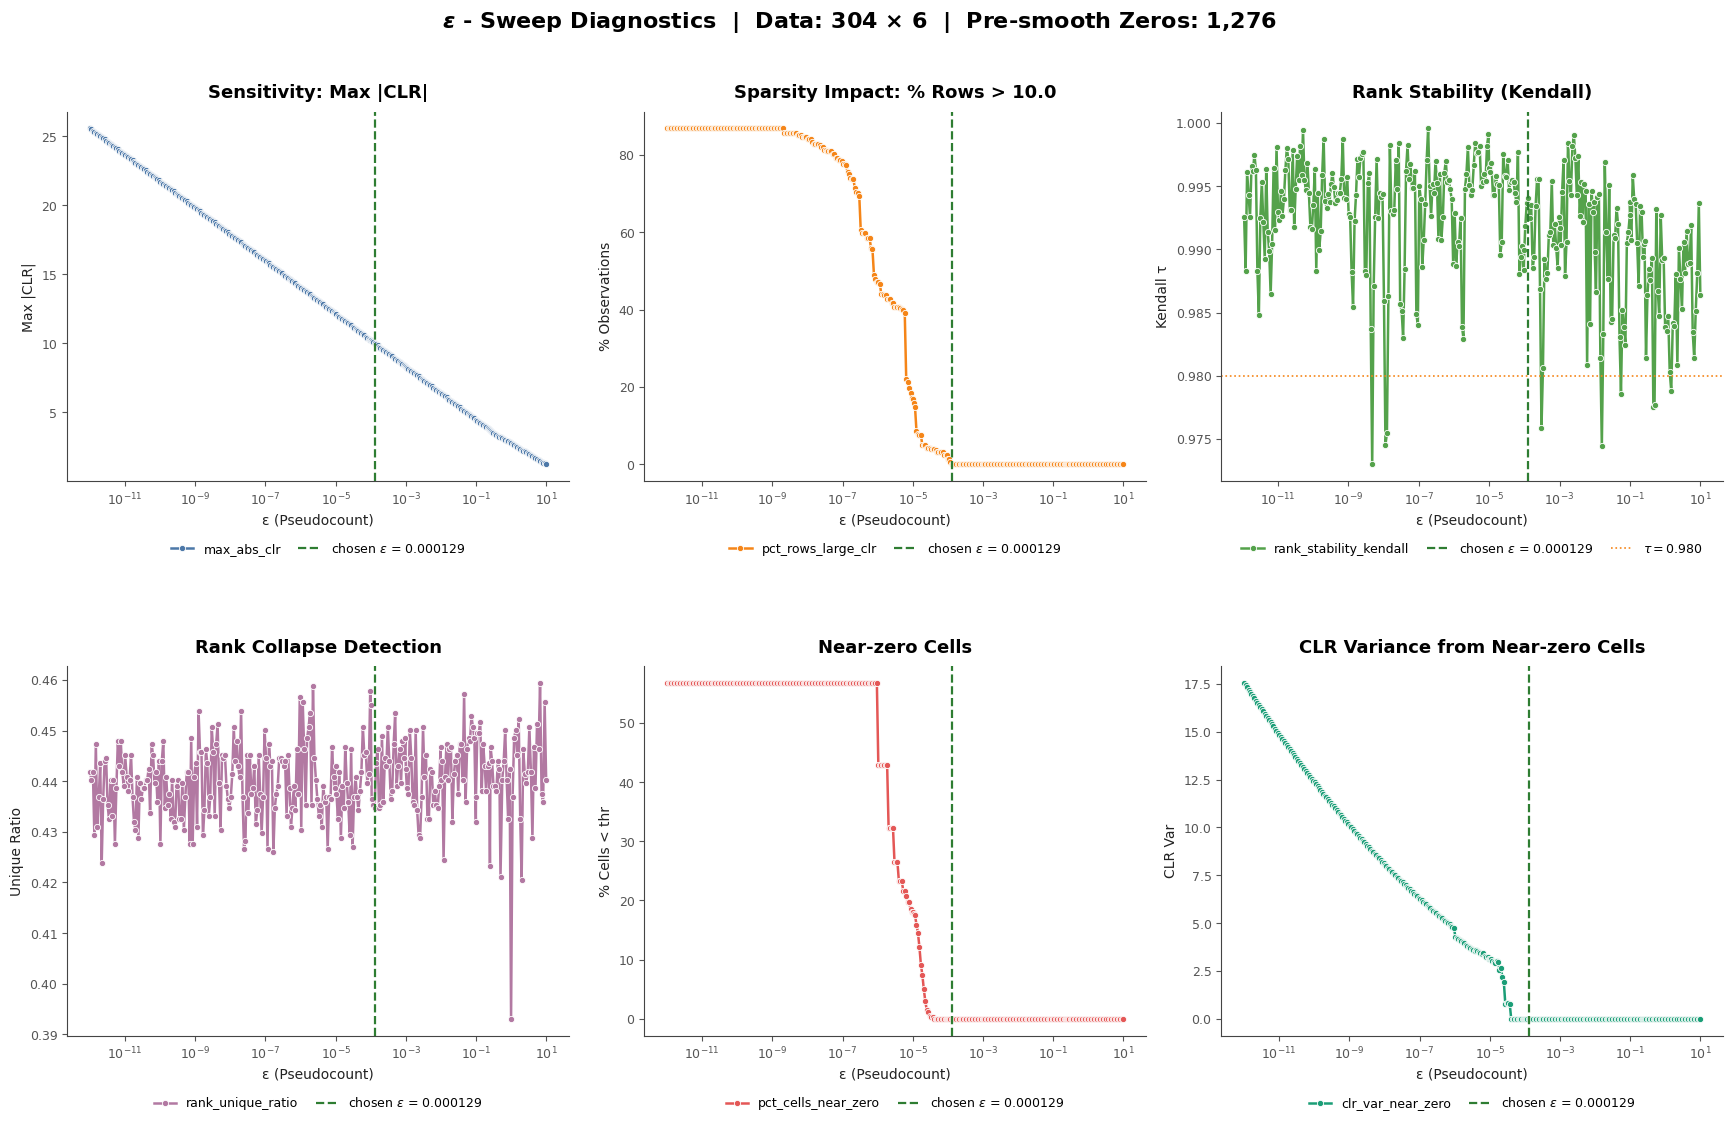

In [14]:
# Find delta constant
epsilon_result_sparse = grid.build_eps_grid(fill_results_sparse['filled_df'])
# Select Optium esp
epsilon_sweep_result_sparse = grid.sweep_epsilon_grid(epsilon_result_sparse['pivot_data'], epsilon_result_sparse['eps_values'], auto_select=True, plot=True)

In [15]:
# Extracts the transition window 
df_view, chosen_eps, prior_eps = utils.get_epsilon_transition(epsilon_sweep_result_sparse, window_prior=5, window_past=5)
df_view

index,status,is_chosen,eps,max_abs_clr,mean_max_abs_clr,pct_rows_large_clr,rank_stability_spearman,rank_stability_kendall,rank_unique_ratio,rank_entropy,zero_contribution_ratio
191,❌ FALSE,,0.0000879530,10.319362,6.431592,2.302632,0.999499,0.990292,0.441338,5.778415,0.574660
192,❌ FALSE,,0.0000968418,10.239133,6.373851,2.302632,0.998701,0.988391,0.457785,5.872446,0.574310
193,❌ FALSE,,0.0001000000,10.212390,6.354603,1.315789,0.999353,0.989986,0.455044,5.865498,0.574190
194,❌ FALSE,,0.0001066288,10.158904,6.316109,1.315789,0.999411,0.991850,0.436404,5.758810,0.573949
195,❌ FALSE,,0.0001174050,10.078675,6.258368,0.657895,0.999644,0.993662,0.435307,5.735208,0.573577
196,✅ TRUE,⭐ [CHOSEN],0.0001292702,9.998446,6.200627,0.000000,0.999886,0.994064,0.434759,5.744360,0.573193
197,✅ TRUE,,0.0001423345,9.918217,6.142886,0.000000,0.999857,0.992450,0.443531,5.777956,0.572798
198,✅ TRUE,,0.0001567191,9.837988,6.085146,0.000000,0.999837,0.993508,0.446272,5.762916,0.572391
199,✅ TRUE,,0.0001725575,9.757759,6.027406,0.000000,0.999156,0.988493,0.434759,5.793587,0.571971
200,✅ TRUE,,0.0001899965,9.677530,5.969666,0.000000,0.999165,0.989379,0.435307,5.735597,0.571538


In [16]:
# PCA for CLR: Sparse
pca_result = pca_anchor.compute_pca(epsilon_sweep_result_sparse['clr_dict'][chosen_eps], epsilon=chosen_eps)


              📊 PCA DATA MANIFEST (ε = 0.000)               
------------------------------------------------------------
[✅] Observations                :                      304
[✅] Included Features           :                        6
[🚫] Excluded                    :                        0
[⚠️] Excluded Not Found          :                        0



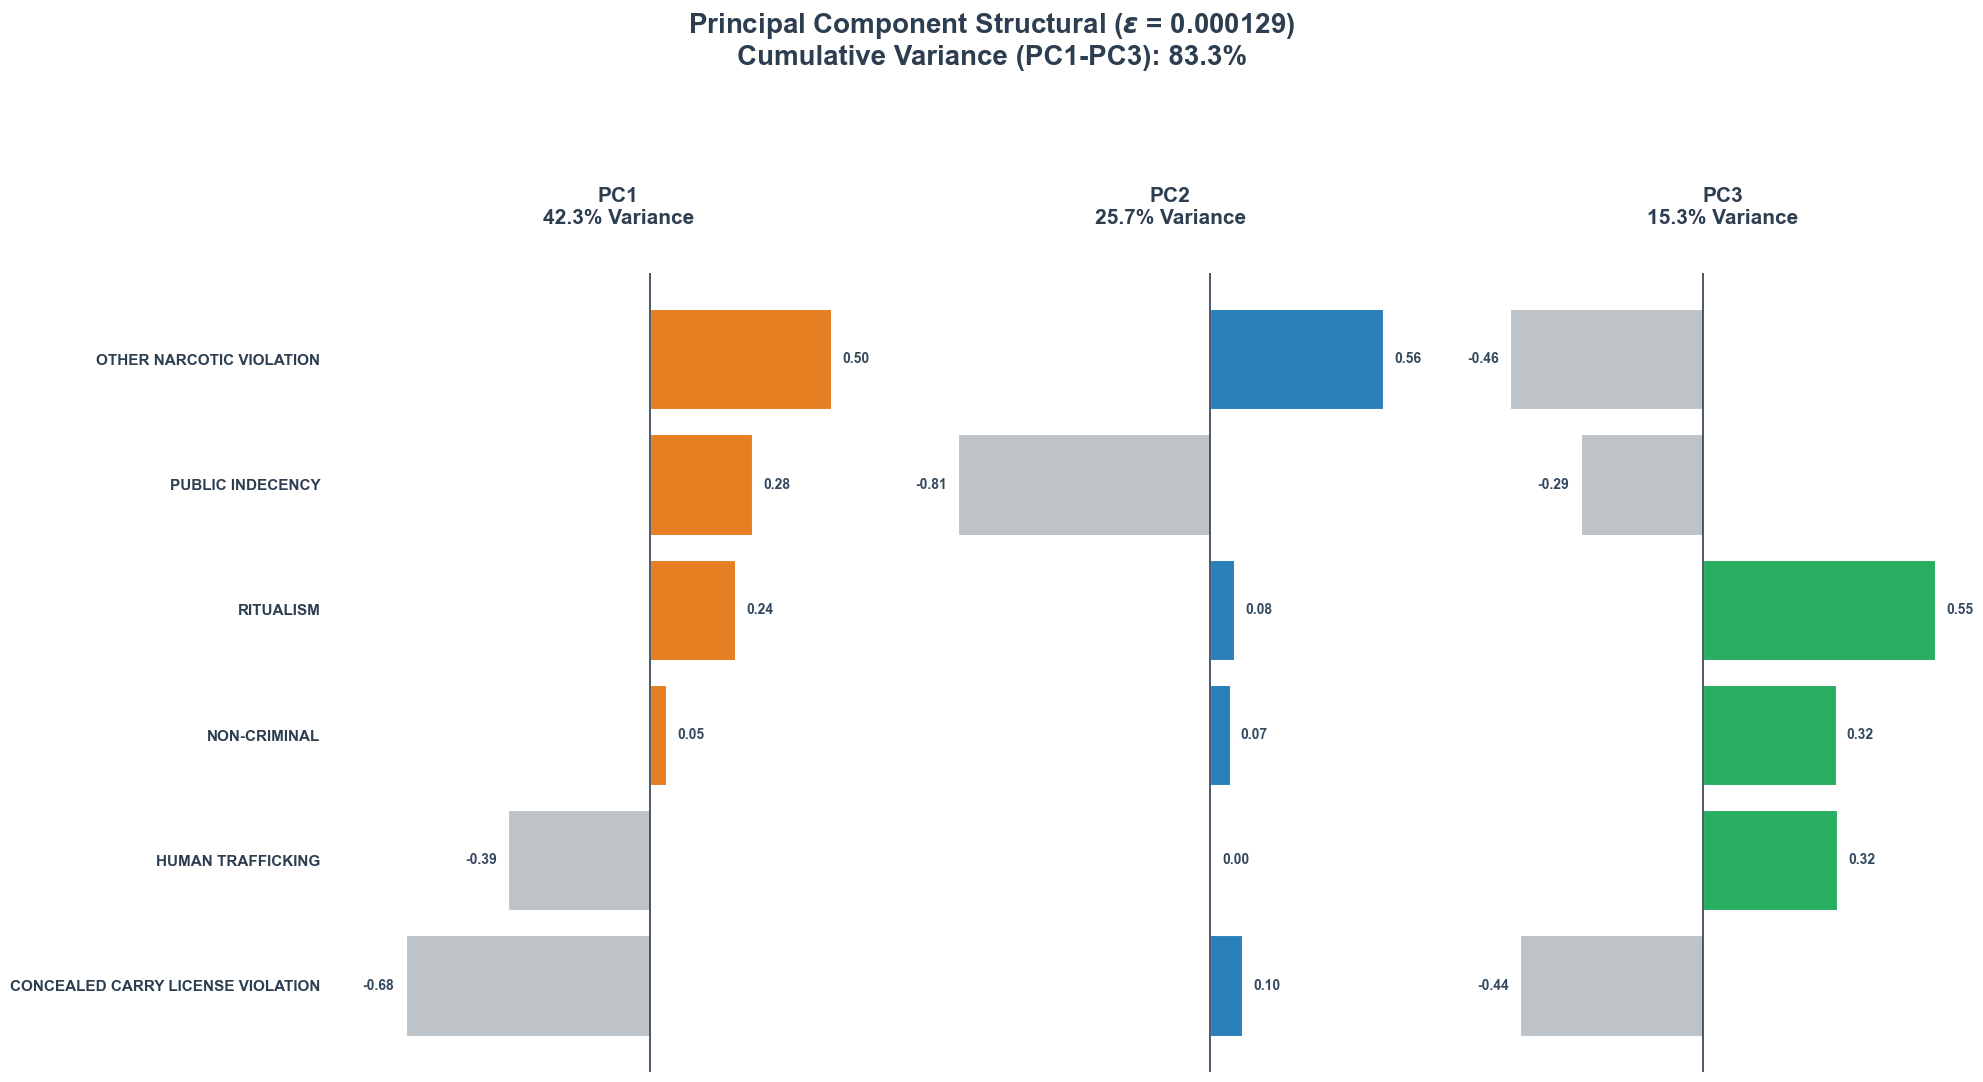

In [17]:
# Plot PCA
_ = pca_anchor.plot_three_loadings(pca_result, epsilon=chosen_eps)

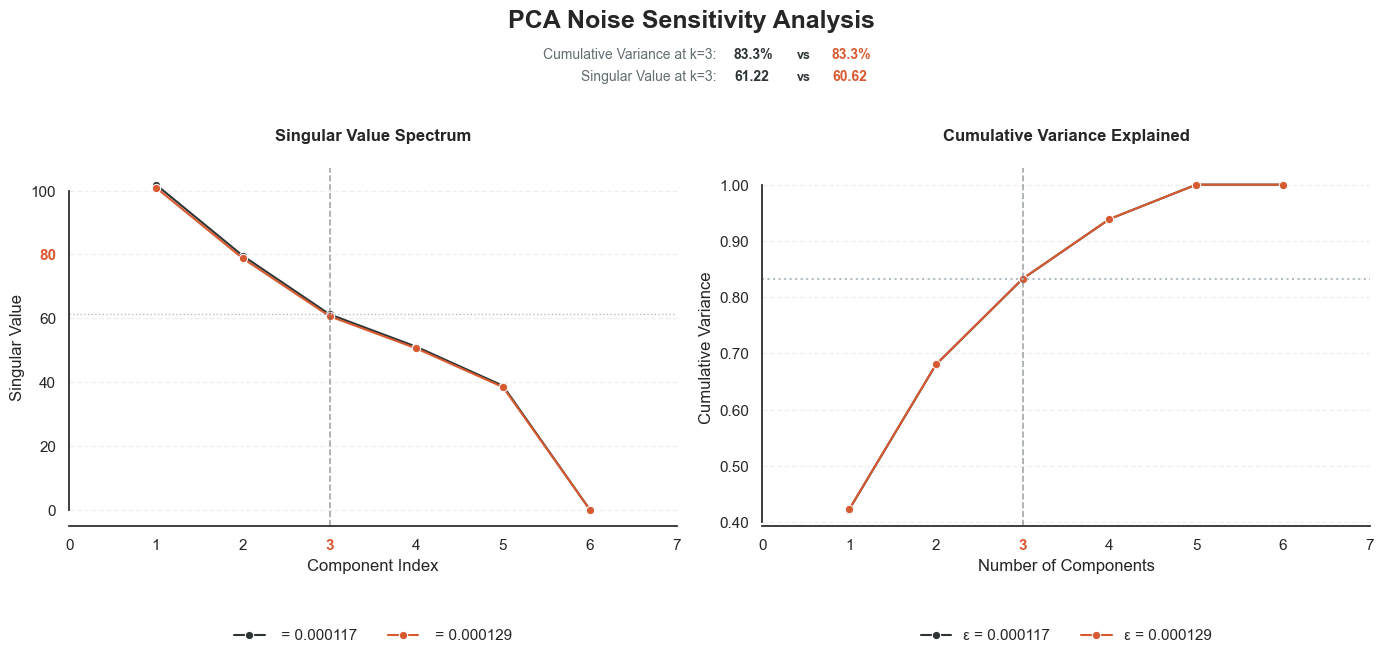

In [18]:
# Prep for PCA Compare
results = pca_prep_comparison(epsilon_sweep_result_sparse,
                              epsilon=chosen_eps, epsilon_alt=prior_eps)
# PCA Noise Sensitivity Analysis Plots
plot.pca_sensitivity_plot(results, k_components=3)


                   🔍 PCA STABILITY CROSS-CHECK                   
                   (ε=0.000129 vs ε=0.000117)                    
                Number of Principal Components: 3                
-----------------------------------------------------------------
⚖️  SV Magnitude Shift (L2)               :       1.3804
📐  Max Subspace Angle                    :        0.14°
💎  Composite Health Score                :       0.9972
-----------------------------------------------------------------
PC1 Robustness (Cosine Similarity) ✅     :       1.0000
PC2 Robustness (Cosine Similarity) ✅     :       1.0000
PC3 Robustness (Cosine Similarity) ✅     :       1.0000



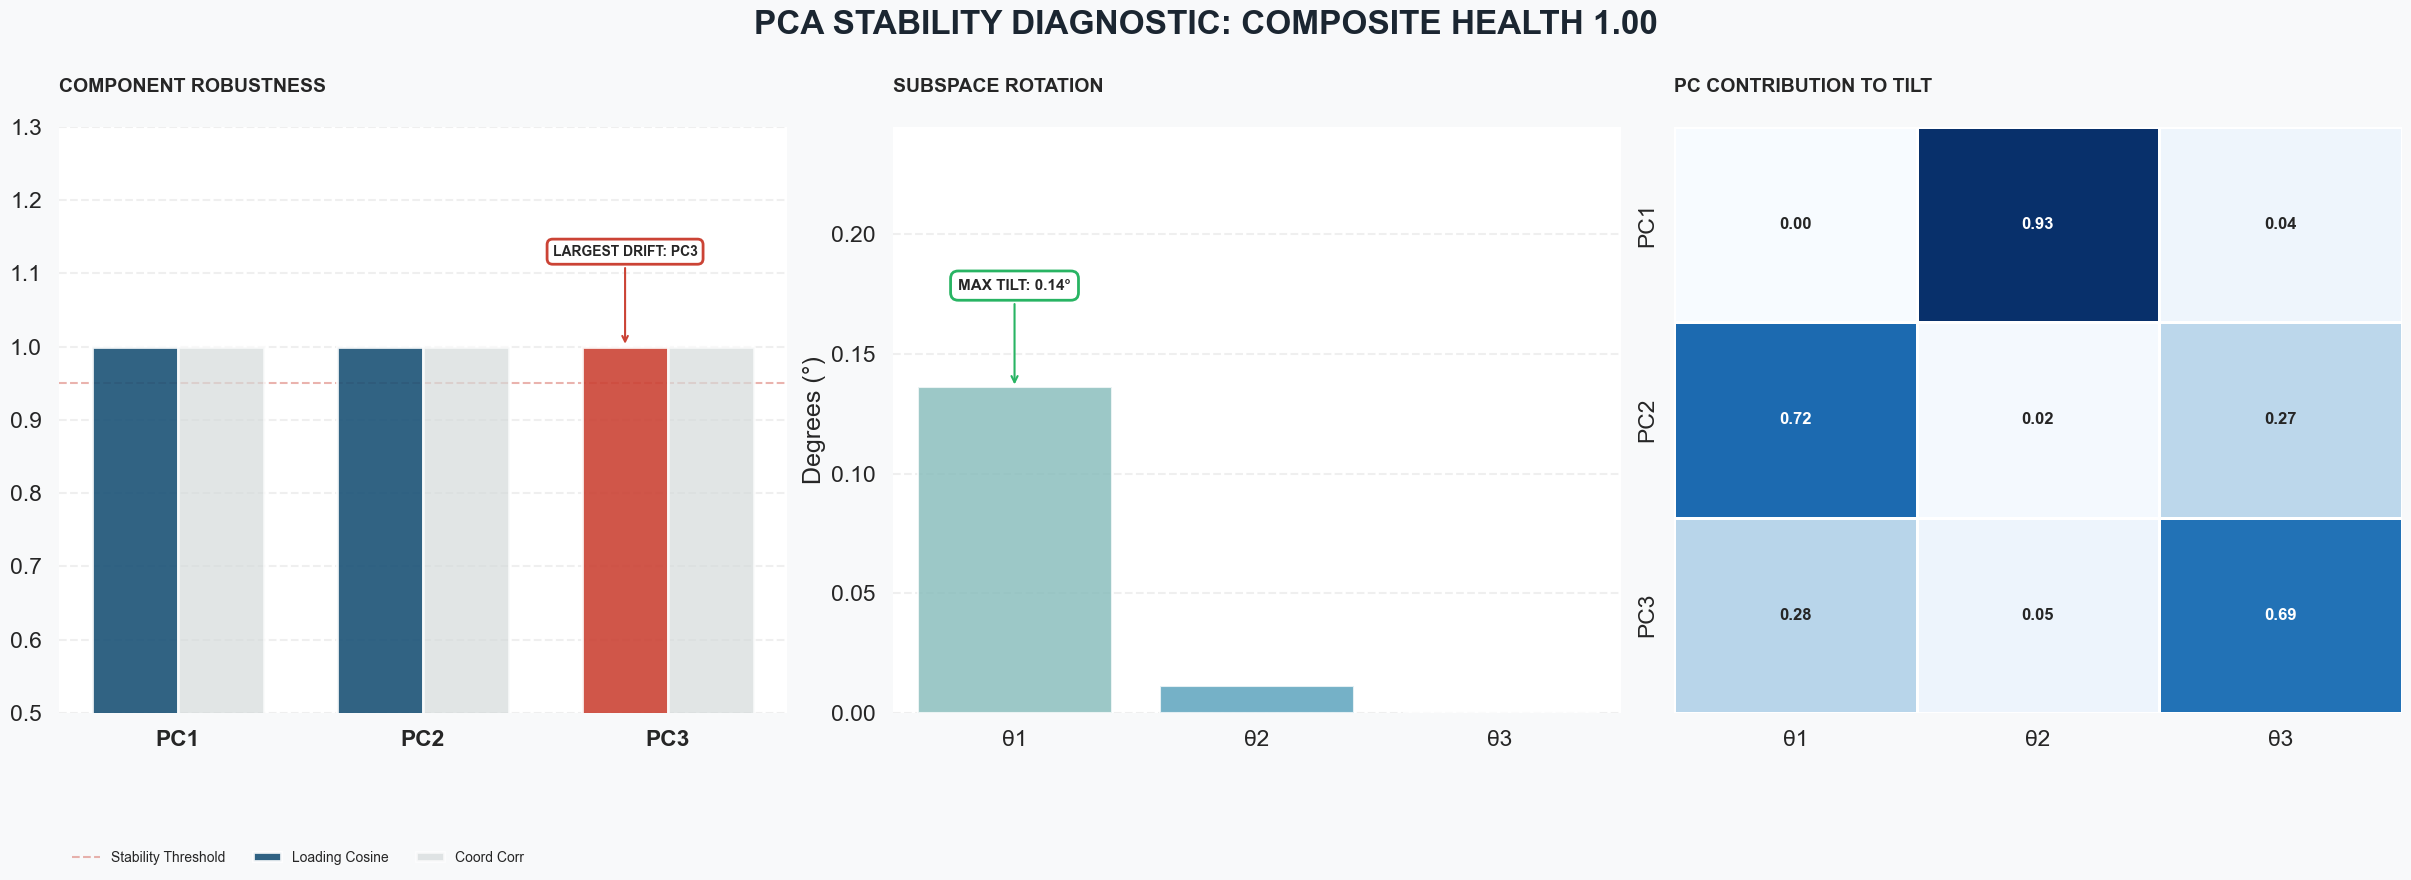

In [19]:
# PCA Stability Check
stability_results_sparse = plot.compare_pca_stability(results, chosen_eps, prior_eps)

#### 📌 Summary

>We tested the stability of the selected pseudocount (ε = 0.000129) by re-running the PCA with a nearby lower value (ε = 0.000117). The results were unchanged: the principal components, explained variance, and number of retained components were identical across both runs. This indicates that the analysis is not sensitive to the exact pseudocount selected, and that nearby ε values produce the same overall structure.

#### Inspect the CLR Dictionary Structure

In [20]:
# Check auto-chosen epsilon
clr_dict = check_clr_health(epsilon_sweep_result_sparse)

================= ERA STRUCTURE ==================
Container Type    : dict
Total Categories  : 6

---------- TARGET EPSILON: 0.0001292702-----------
Dimensions        : 304 months x 6 categories
Temporal Range    : 2001-01 to 2026-04
Primary Features  : CONCEALED CARRY LICENSE VIOLATION, HUMAN TRAFFICKING, NON-CRIMINAL ...
Numerical Health  : 2.37e-15 (🟢 OPTIMAL)


#### Aitchison Plot for the chosen epsilon

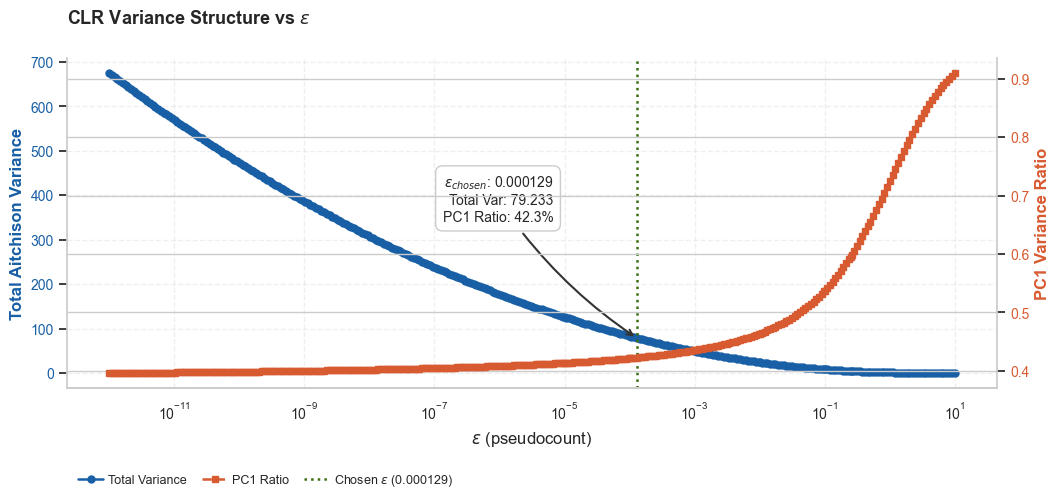

In [21]:
# Aitchison plot for the chosen epsilon (sweep_epsilon_grid() output dictionary:['clr_dict'])
aitchison_results = plot.plot_aitchison(clr_dict,chosen_eps)

#### Stability Diagnostics

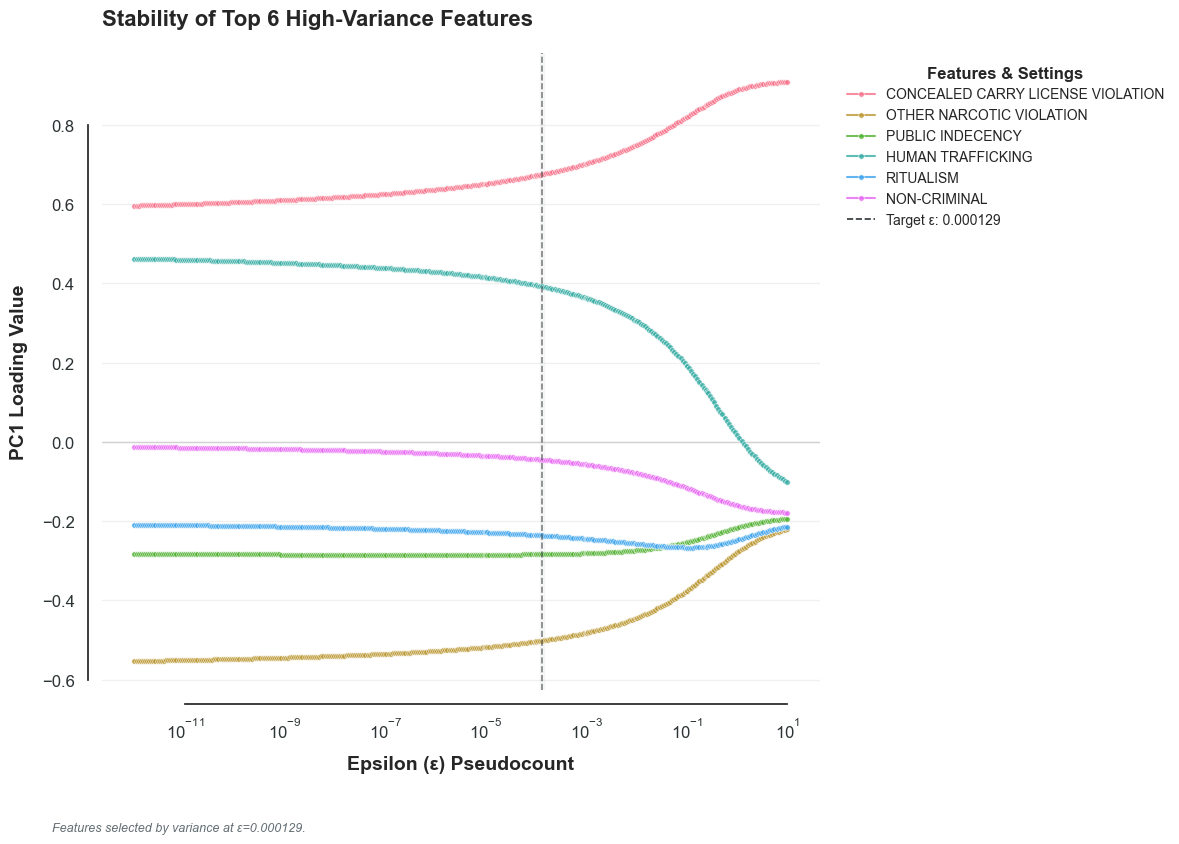

In [22]:
# PC Loading Stability Plot for the chosen epsilon for all
pc1_stability_results = plot.plot_pc1_loading_stability(clr_dict, chosen_eps=chosen_eps, top_k=10)

#### 📌 Summary

> The chosen $\varepsilon=0.000129$ sits in a stable region. The PC1 loadings barely change as $\varepsilon$ varies over many orders of magnitude, and the data still has meaningful structure across multiple dimensions (PC1 accounts for only 42% of the variance, not all of it). The choice is robust.

### Dense

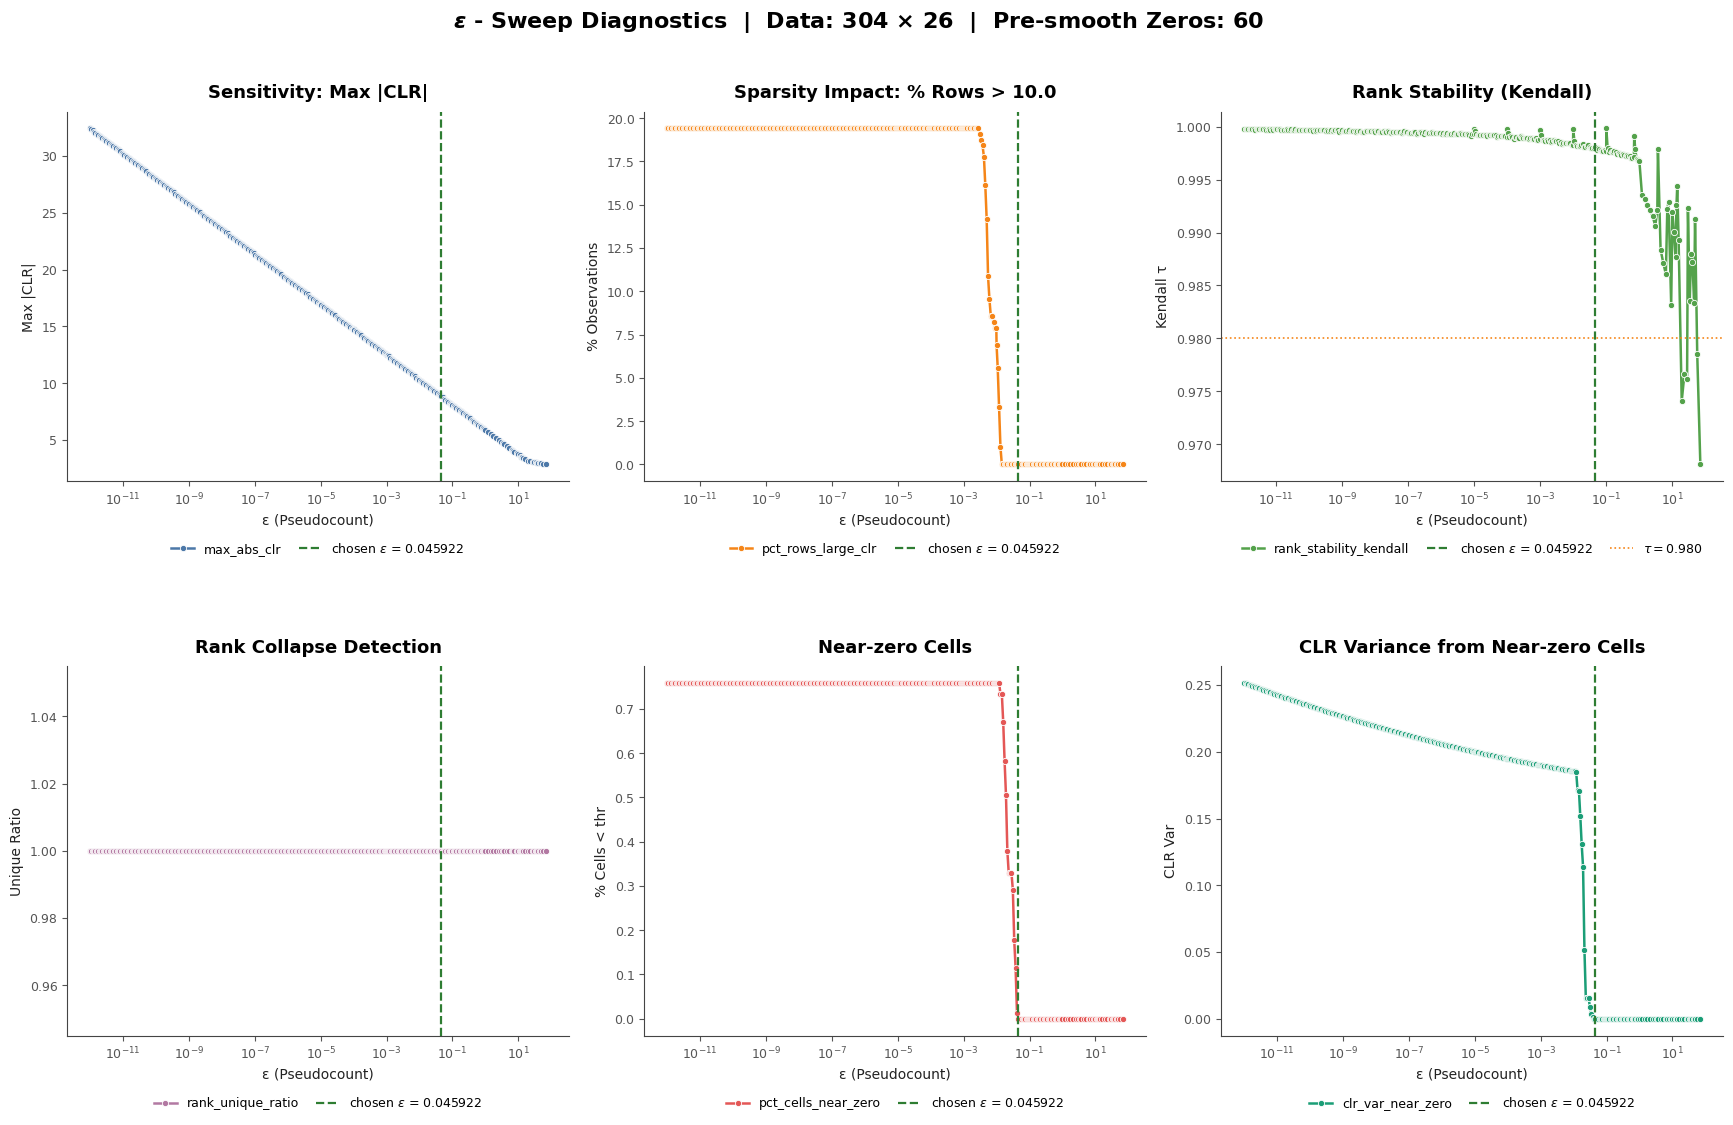

In [23]:
# Find delta constant
epsilon_result_dense = grid.build_eps_grid(fill_results_dense['filled_df'])
# Select Optium esp
epsilon_sweep_result_dense = grid.sweep_epsilon_grid(epsilon_result_dense['pivot_data'], epsilon_result_dense['eps_values'], auto_select=True, plot=True)

In [24]:
# Extracts the transition window 
df_view, chosen_eps, prior_eps = utils.get_epsilon_transition(epsilon_sweep_result_dense, window_prior=20, window_past=5)
df_view

index,status,is_chosen,eps,max_abs_clr,mean_max_abs_clr,pct_rows_large_clr,rank_stability_spearman,rank_stability_kendall,rank_unique_ratio,rank_entropy,zero_contribution_ratio
239,❌ FALSE,,0.0073721781,10.584960,5.694947,8.552632,1.000000,0.998423,1.000000,8.247928,0.113511
240,❌ FALSE,,0.0081172265,10.492394,5.676691,8.223684,1.000000,0.998425,1.000000,8.247928,0.114214
241,❌ FALSE,,0.0089375712,10.399829,5.658404,7.894737,1.000000,0.998307,1.000000,8.247928,0.114918
242,❌ FALSE,,0.0098408216,10.307264,5.640084,7.894737,1.000000,0.998293,1.000000,8.247928,0.115624
243,❌ FALSE,,0.0100000000,10.291837,5.637027,6.907895,1.000000,0.999751,1.000000,8.247928,0.115742
244,❌ FALSE,,0.0108353565,10.214701,5.621727,5.592105,1.000000,0.998624,1.000000,8.247928,0.116330
245,❌ FALSE,,0.0119304013,10.122138,5.603329,3.289474,1.000000,0.998258,1.000000,8.247928,0.117038
246,❌ FALSE,,0.0131361137,10.029576,5.584888,0.986842,1.000000,0.998159,1.000000,8.247928,0.117747
247,❌ FALSE,,0.0144636780,9.937015,5.566397,0.000000,1.000000,0.998183,1.000000,8.247928,0.118456
248,❌ FALSE,,0.0159254089,9.844455,5.547853,0.000000,1.000000,0.998186,1.000000,8.247928,0.119167


#### Inspect the CLR Dictionary Structure

In [25]:
# Check auto-chosen epsilon
clr_dict = check_clr_health(epsilon_sweep_result_dense)

================= ERA STRUCTURE ==================
Container Type    : dict
Total Categories  : 26

---------- TARGET EPSILON: 0.0459220118-----------
Dimensions        : 304 months x 26 categories
Temporal Range    : 2001-01 to 2026-04
Primary Features  : ARSON, ASSAULT, BATTERY ...
Numerical Health  : 1.41e-14 (🟢 OPTIMAL)


### Build the CLR Matrix & Slice Into Eras

In [22]:
# Build CLR Matrix into Eras
clr_era = clr.slice_clr_into_eras(clr_dict, cfg.era_boundaries, eps=epsilon)


 📅  CLR TEMPORAL SEGMENTATION REPORT (ε = 0.02)
  • Total Matrix       : 304 months x 26 crimes
  • Date Horizon       : 2001-01 to 2026-04
------------------------------------------------------------
  Era Label          | Span (T)     | Date Range          
------------------------------------------------------------
  Pre-COVID          | 230 months   | 2001-01 to 2020-02
  COVID              | 34 months    | 2020-03 to 2022-12
  Post-COVID         | 40 months    | 2023-01 to 2026-04



## Compute Per-Era Distributional Parameters

In [23]:
# Compute Per-Era Distribution
eras_stat = clr.compute_era_distribution_parameters(clr_era, sparse_cats=None, verbose=True)
# sparse_cats = ['Gambling', 'Gambling', 'Involuntary Manslaughter / Reckless Homicide', 'Prostitution']


MEAN CLR VECTOR PER ERA
                                              Pre-COVID   COVID  Post-COVID  COVID_minus_Pre-COVID  Post-COVID_minus_Pre-COVID  Post-COVID_minus_COVID
fbi_code_desc                                                                                                                                         
Aggravated Assault                               0.7208  1.5766      1.5323                 0.8558                      0.8115                 -0.0443
Aggravated Battery                               1.1880  1.7134      1.5840                 0.5254                      0.3960                 -0.1294
Arson                                           -1.6192 -1.0497     -1.2738                 0.5695                      0.3454                 -0.2241
Burglary                                         1.9378  1.6398      1.4837                -0.2980                     -0.4542                 -0.1561
Criminal Sexual Assault                         -0.4345  0.1518      

### Sanity Check
`era_covs_lw`: LW takes your noisy estimated relationships between crime types and asks, "How much of this is real signal vs. sampling noise?" It preserves the signal and reduces noise toward zero.

In [24]:
# Configuration for Audit Report (Sanity Checxk)
audit_config = {
    'era_covs': "Covariance Matrix Geometry",
    'era_means': "Era Mean Matrix Structure",
    'era_stds': "Era Std Deviation Matrix Structure"
}

print(f"{'REPORT CATEGORY':<30} | {'DIMENSIONS':<20}")
print("=" * 60)

for key, title in audit_config.items():
    data = eras_stat.get(key)
    if data is None: continue

    print(f"\n# {title}")

    # Case A: Covariance Dictionaries (The interaction maps)
    if isinstance(data, dict):
        for era, matrix in data.items():
            # Shows 23x23 or 26x26 interaction grid
            print(f"  {era:<28}: {matrix.shape[0]} x {matrix.shape[1]} (Square)")

    # Case B: DataFrames (The summary tables)
    elif hasattr(data, 'shape'):
        rows, cols = data.shape
        # Explicit labeling: 3 Eras + 3 Calculated Shifts
        print(f"  {'Integrated Dataset':<28}: {rows} Rows x {cols} Columns")
        print(f"    -> {rows} Crime Categories analyzed across:")
        print(f"    -> [3 Primary Eras] + [3 Calculated Shift Columns]")

REPORT CATEGORY                | DIMENSIONS          

# Covariance Matrix Geometry
  Pre-COVID                   : 26 x 26 (Square)
  COVID                       : 26 x 26 (Square)
  Post-COVID                  : 26 x 26 (Square)

# Era Mean Matrix Structure
  Integrated Dataset          : 26 Rows x 6 Columns
    -> 26 Crime Categories analyzed across:
    -> [3 Primary Eras] + [3 Calculated Shift Columns]

# Era Std Deviation Matrix Structure
  Integrated Dataset          : 26 Rows x 6 Columns
    -> 26 Crime Categories analyzed across:
    -> [3 Primary Eras] + [3 Calculated Shift Columns]


## Visualize the Mean/Volatility CLR Shift Heatmap

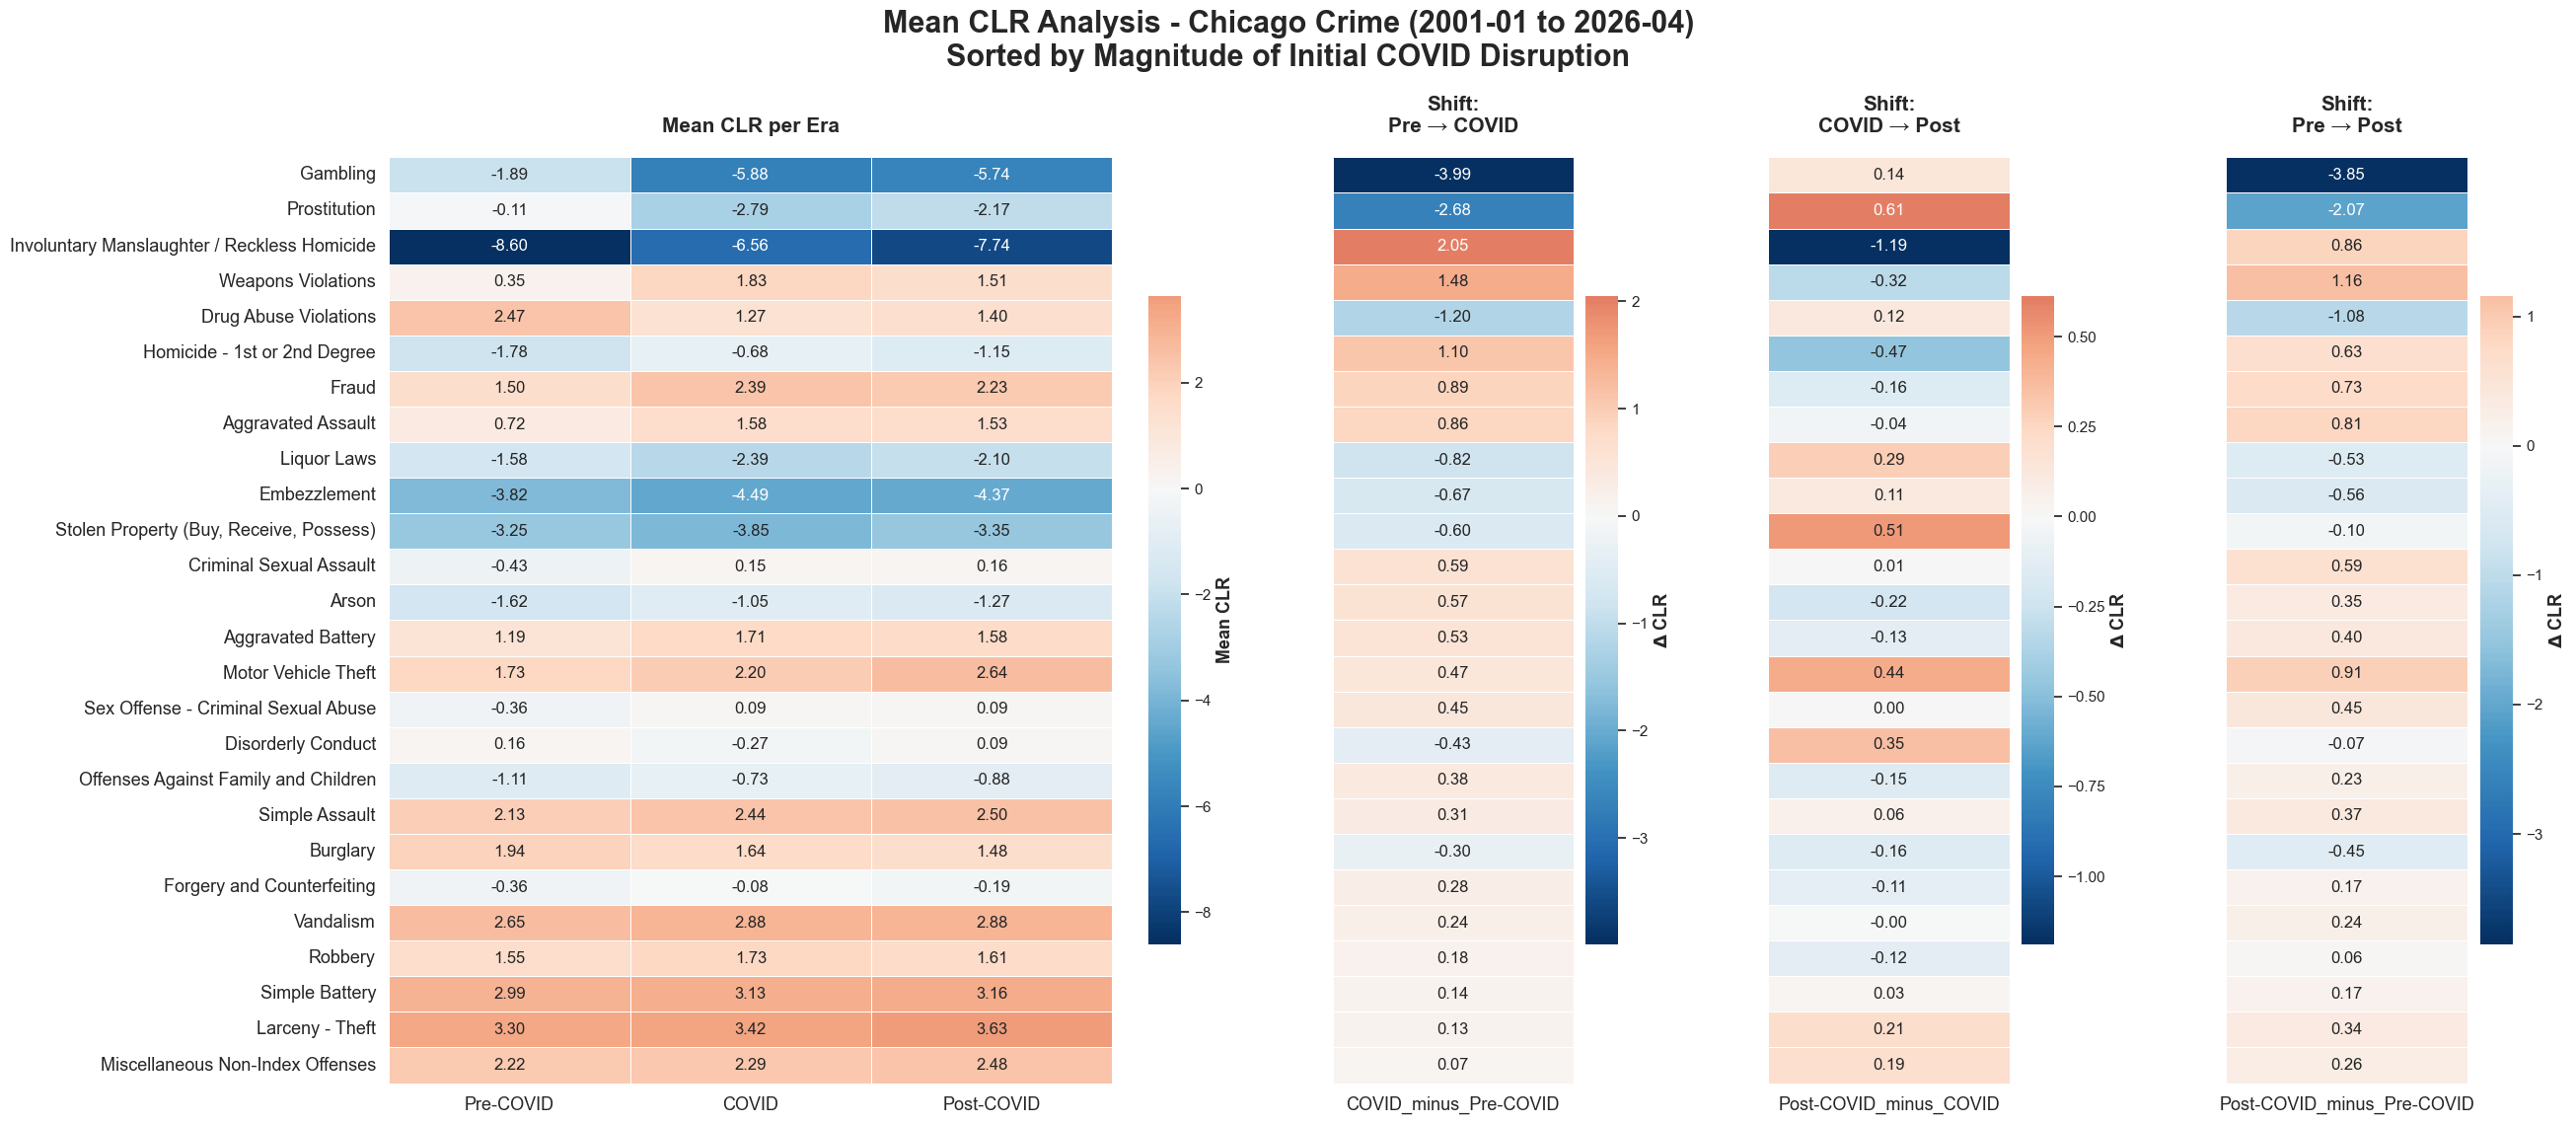

In [25]:
# Heat Map for Mean
plot.plot_era_heatmaps(eras_stat, stat_type='mean')

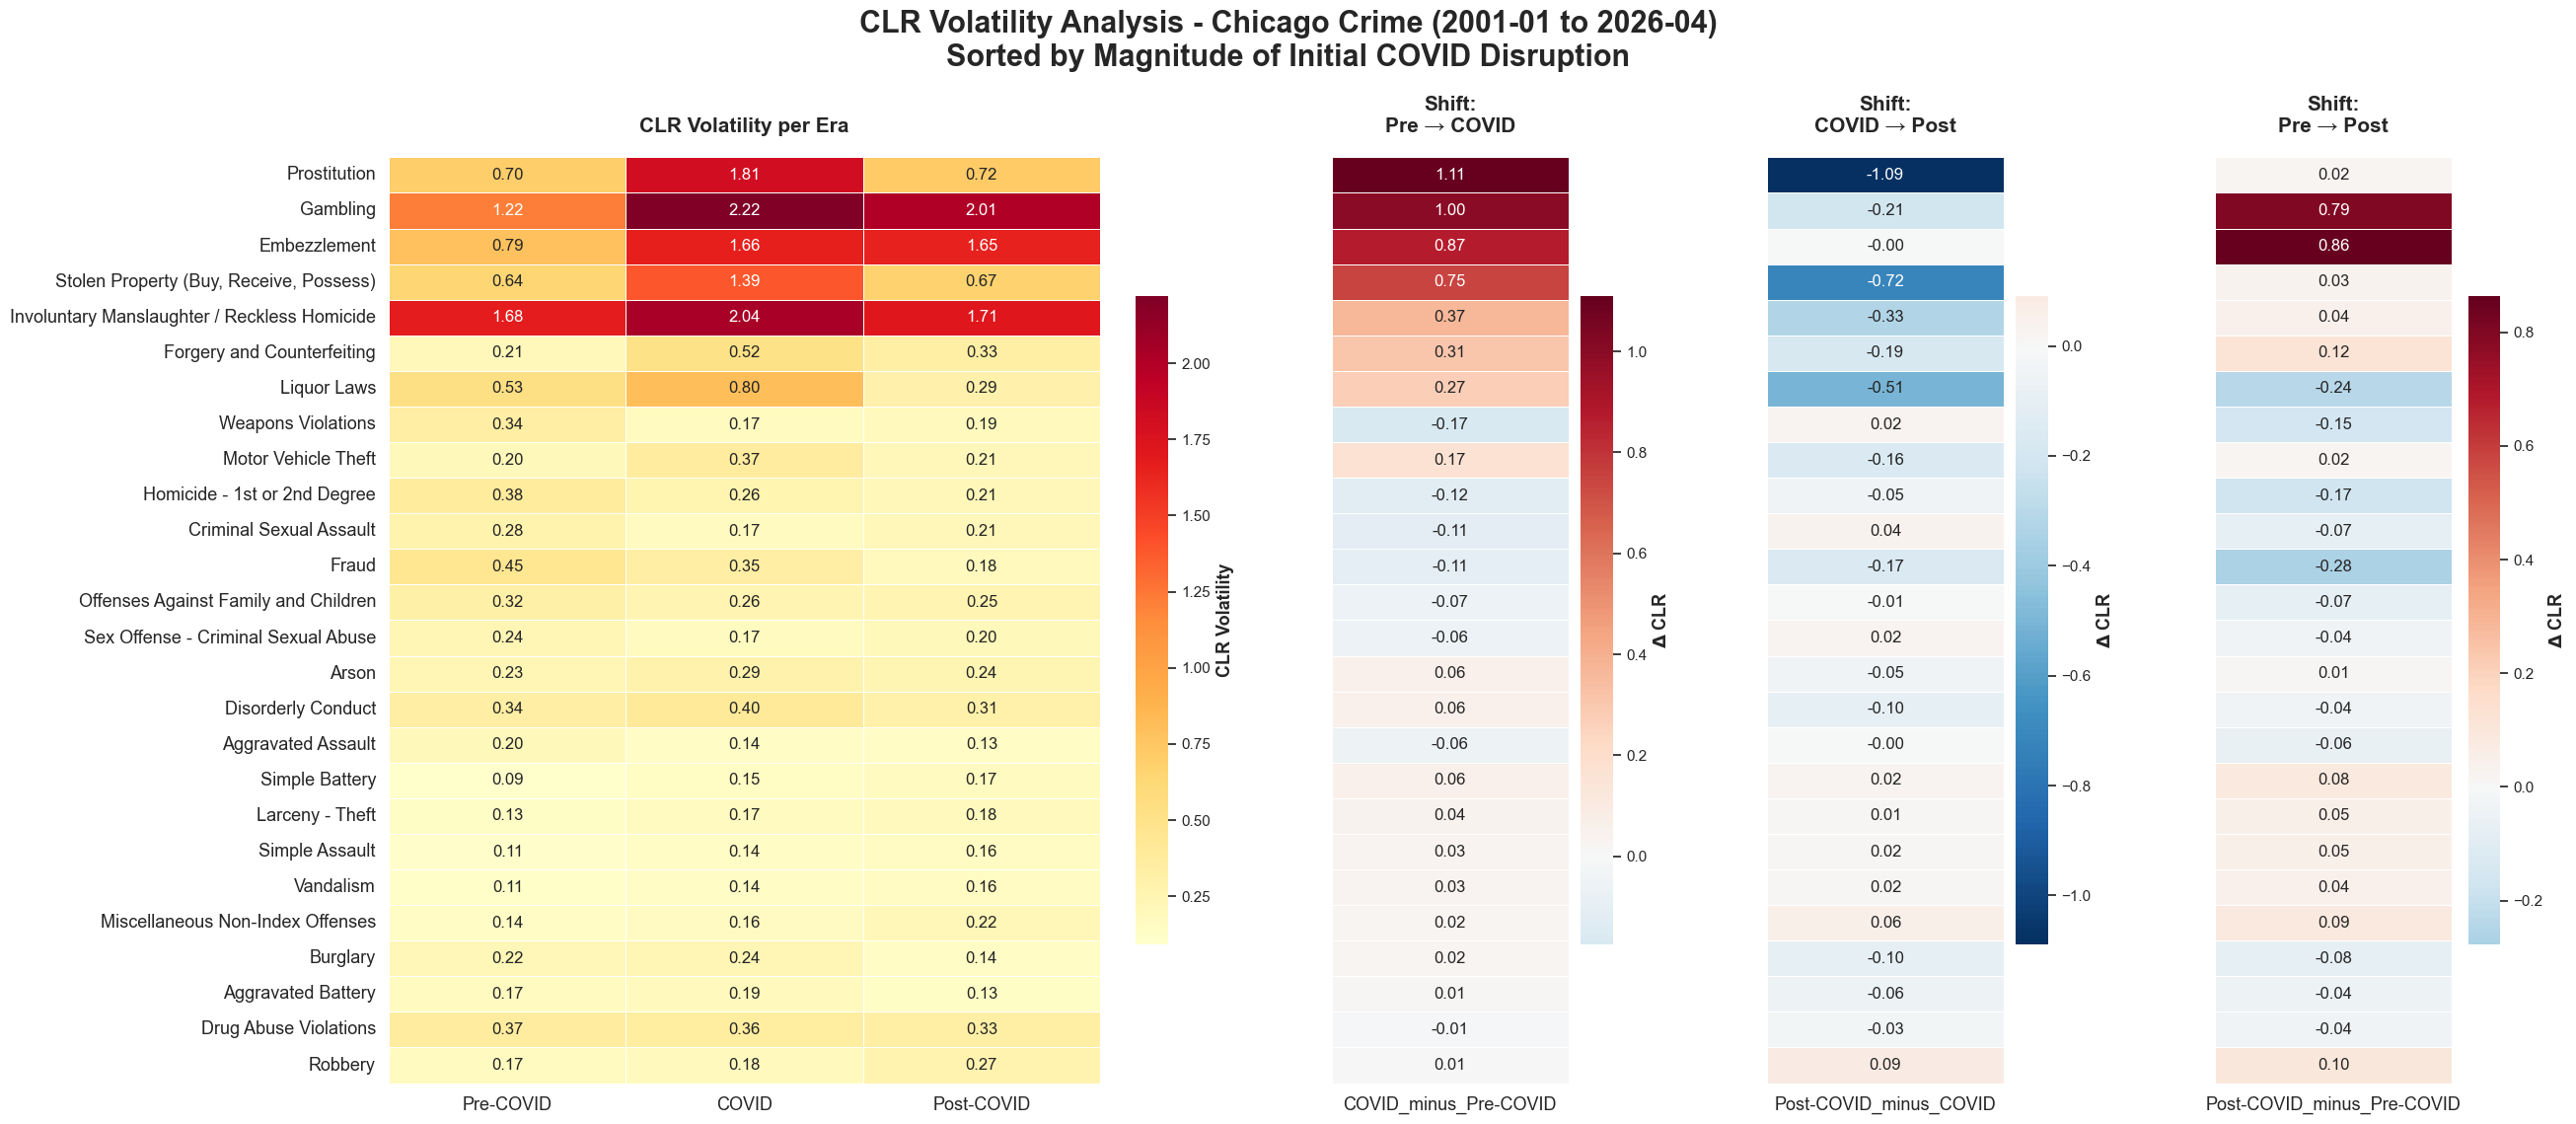

In [26]:
# Heat Map for Volatility
plot.plot_era_heatmaps(eras_stat, stat_type='std')

## Stationarity Testing & Block Bootstrap on the CLR series 
The CLR-transformed series spans 304 months (Jan 2001 - April 2026) across three structurally distinct eras separated by known administrative breakpoints. Over this period, Chicago crime composition was subject to major policy shifts (gambling legalization, FOSTA-SESTA, CPD consent decree), demographic changes, and a global pandemic, all of which introduced sustained distributional shifts inconsistent with stationarity. Non-stationarity is therefore theoretically expected and consistent with the structural break detection framework adopted in this analysis. We will still conduct the test to determine whether the CLR-transformed series appears stationary or non-stationary.

**Note:**
>Standard ADF and KPSS tests assume no structural breaks and independent observations. Given the known breakpoints at months 230 (Feb 2020) and 264 (Dec 2022), compositional constraint across K=26 series, and structural zeros in sparse categories, results should be interpreted as indicative rather than definitive. Conflicting results between ADF and KPSS will be reported transparently.

### Step 6a: Stationarity Testing

In [27]:
# Reconstruct clr_df from clr_era
clr_df = pd.concat([
    clr_era['Pre-COVID'],
    clr_era['COVID'],
    clr_era['Post-COVID']
])

print("clr_df shape:", clr_df.shape)
print("Raw Counts with Filled Data shape:", fill_results['filled_df'].shape)
print("First 3 index:", clr_df.index[:3].tolist())
print("Last  3 index:", clr_df.index[-3:].tolist())

clr_df shape: (304, 26)
Raw Counts with Filled Data shape: (7904, 5)
First 3 index: [Timestamp('2001-01-01 00:00:00'), Timestamp('2001-02-01 00:00:00'), Timestamp('2001-03-01 00:00:00')]
Last  3 index: [Timestamp('2026-02-01 00:00:00'), Timestamp('2026-03-01 00:00:00'), Timestamp('2026-04-01 00:00:00')]


In [42]:
# Stationarity - CLR
sts_df = clr.run_stationarity_analysis(clr_df, fill_results['filled_df'], era_boundaries=cfg.era_boundaries, 
                                       seasonal_cycle=12, sparse_threshold=0.05, verbose=True)


📊 STATIONARITY DASHBOARD Total: 26
  Dense  : 24 
  Sparse : 2   (@ > 5.0%)

------------------------------------------------------------------------------------
  ⚠️  Involuntary Manslaughter / Reckless Homicide :  76.6% zeros
  ⚠️  Gambling                                     :   9.2% zeros
------------------------------------------------------------------------------------

🔍 DETAILED STATIONARITY REPORT (Dense)
   Category                                          Status
-------------------------------------------------- ---------------------------------
  🔴 Aggravated Assault                            │ Agree - Non-Stationary
  🔴 Aggravated Battery                            │ Agree - Non-Stationary
  🔴 Arson                                         │ Agree - Non-Stationary
  🔴 Burglary                                      │ Agree - Non-Stationary
  🔴 Criminal Sexual Assault                       │ Agree - Non-Stationary
  🔴 Disorderly Conduct                            │ Agree - 


      STRUCTURAL BREAK DIAGNOSTIC: Involuntary Manslaughter / Reckless Homicide      
  ▶ BREAK POINT     : 2017-11
  ▶ ZA STATISTIC    : -4.947
  ▶ ADJ P-VALUE     : N/A (SPARSE) | STATUS: UNRELIABLE (SPARSE)

  [ SEGMENT STATISTICS ]
              count      mean       std       min       max
  PRE-BREAK   203.0 -8.866089  1.407196 -9.822992 -4.763516
  POST-BREAK  102.0 -7.064819  2.019725 -9.214762 -4.069894

  ▶ MEAN SHIFT (Δ)  : +1.8013



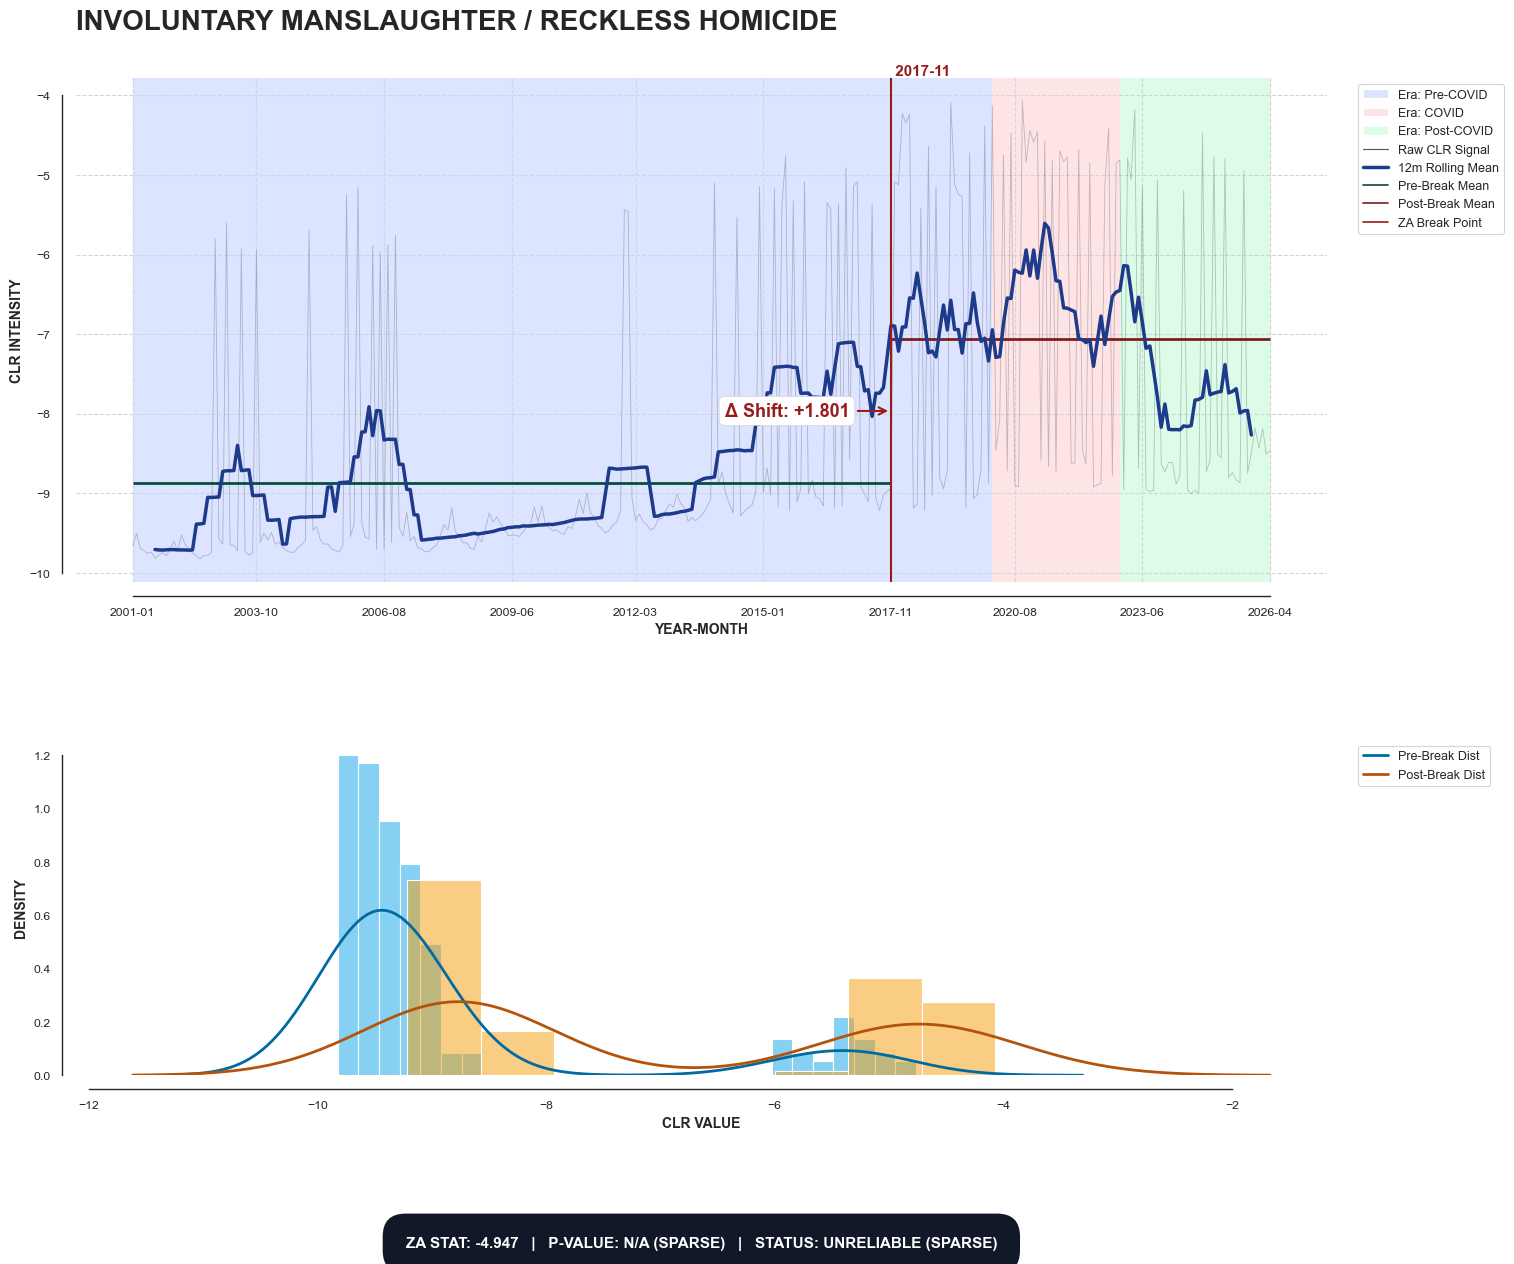

In [29]:
# Initialize values
window  = 12
category = 'Involuntary Manslaughter / Reckless Homicide'
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
plot.plot_structural_break(
    clr_df, 
    category, 
    break_date=za_date,
    window=window,
    za_stat=za_stat, 
    za_p_adj=za_p_adj, 
    era_boundaries=cfg.era_boundaries, 
    verbose=True
)


                        STRUCTURAL BREAK DIAGNOSTIC: Gambling                        
  ▶ BREAK POINT     : 2020-01
  ▶ ZA STATISTIC    : -4.414
  ▶ ADJ P-VALUE     : N/A (SPARSE) | STATUS: UNRELIABLE (SPARSE)

  [ SEGMENT STATISTICS ]
              count      mean       std       min      max
  PRE-BREAK   229.0 -1.859244  1.134180 -8.580169 -0.37859
  POST-BREAK   76.0 -5.823375  2.103726 -9.023751 -2.85491

  ▶ MEAN SHIFT (Δ)  : -3.9641



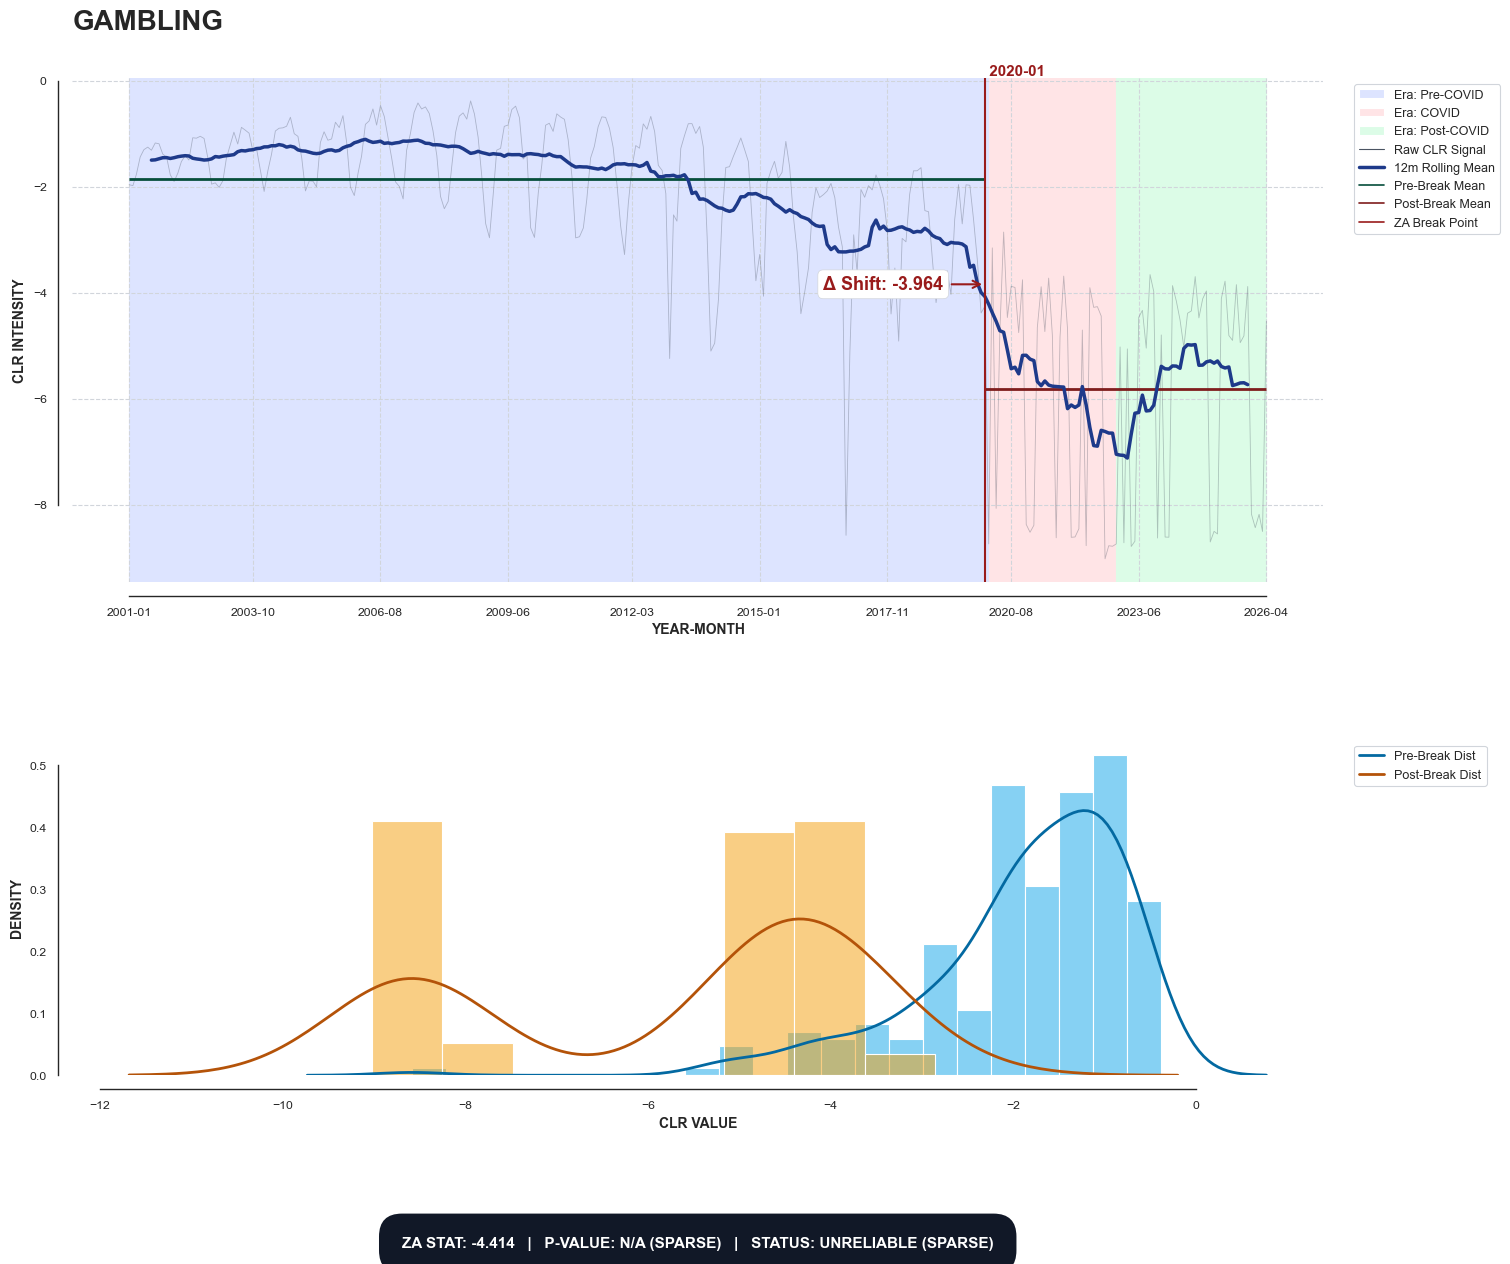

In [30]:
# Initialize values
category = 'Gambling'
row = sts_df.loc[category, ['za_date', 'za_stat', 'za_p_adj']]
za_date, za_stat, za_p_adj = row
# Plot
# Fixed Function Call
plot.plot_structural_break(
    clr_df, 
    category, 
    break_date=za_date,
    window=window,
    za_stat=za_stat, 
    za_p_adj=za_p_adj, 
    era_boundaries=cfg.era_boundaries, 
    verbose=True
)

### Step 6b: Block Bootstrap Test

In [31]:
# Bootstrap Comparison of Eras
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide', 'Gambling'
]

# Pre-COVID vs COVID
bootstrap_pc = clr.run_era_comparison(
    clr_era['Pre-COVID'], clr_era['COVID'],
    label1='Pre-COVID', label2='COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True
)


🧬 BOOTSTRAP INFERENCE: Pre-COVID vs COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: Pre-COVID vs COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Weapons Violations                      1.4763       4.5189     0.0001     0.0002   ✨ Significant
Aggravated Assault                      0.8558       4.5077     0.0001     0.0002   ✨ Significant
Drug Abuse Violations                  -1.2014      -3.2567     0.0001     0.0002   ✨ Significant
Homicide - 1st or 2nd Degree            1.0983       2.9836     0.0001     0.0002   ✨ Significant
Aggravated Battery                      0.5254       2.9800     0.0001     0.0002   ✨ Significant
Prostitution                           -2.6805      -2.9090     0.0001     0.0002   ✨ Significant
Gambling                               -3.9902      -2.8708     0.0001         --   📌 SPARSE/BYPASS
Simple Assault 

In [32]:
# COVID vs Post-COVID
bootstrap_cp = clr.run_era_comparison(
    clr_era['COVID'], clr_era['Post-COVID'],
    label1='COVID', label2='Post-COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True

)


🧬 BOOTSTRAP INFERENCE: COVID vs Post-COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: COVID vs Post-COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Homicide - 1st or 2nd Degree           -0.4677      -1.9702     0.0010     0.0240   ✨ Significant
Weapons Violations                     -0.3195      -1.7515     0.0026     0.0312   ✨ Significant
Motor Vehicle Theft                     0.4394       1.4756     0.0145     0.0821   🚫 Not Significant
Larceny - Theft                         0.2072       1.1645     0.0170     0.0821   🚫 Not Significant
Disorderly Conduct                      0.3539       0.9909     0.0263     0.1035   🚫 Not Significant
Miscellaneous Non-Index Offenses        0.1931       0.9763     0.0302     0.1035   🚫 Not Significant
Arson                                  -0.2241      -0.8364     0.0345     0.1035   🚫 Not Signifi

In [33]:
# Pre-COVID vs Post-COVID
bootstrap_pp = clr.run_era_comparison(
    clr_era['Pre-COVID'], clr_era['Post-COVID'],
    label1='Pre-COVID', label2='Post-COVID',
    sparse_cats=sparse_cats,
    block_size=6,
    seed=_RANDOM_STATE, verbose=True
)


🧬 BOOTSTRAP INFERENCE: Pre-COVID vs Post-COVID
📦 Blocks: 6 | 🔄 Iters: 10,000 | 👥 Groups: Pre-COVID vs Post-COVID

CATEGORY                                Δ MEAN     HEDGES G      P-VAL    FDR ADJ   STATUS
────────────────────────────────────────────────────────────────────────────────────────────────────
Motor Vehicle Theft                     0.9086       4.5706     0.0001     0.0001   ✨ Significant
Aggravated Assault                      0.8115       4.3086     0.0001     0.0001   ✨ Significant
Weapons Violations                      1.1567       3.5510     0.0001     0.0001   ✨ Significant
Simple Assault                          0.3692       3.1891     0.0001     0.0001   ✨ Significant
Drug Abuse Violations                  -1.0772      -2.9546     0.0001     0.0001   ✨ Significant
Prostitution                           -2.0677      -2.9242     0.0001     0.0001   ✨ Significant
Gambling                               -3.8528      -2.8177     0.0001         --   📌 SPARSE/BYPASS
Larce

📌 Summary

> Block-bootstrap inference across the three regime comparisons reveals a clear and persistent structural transition in the composition of crime in Chicago. The **Pre-COVID to COVID** transition produced widespread disruption where **23 of 24** dense crime categories shifted significantly after **BH-FDR correction**, with especially large standardized effects in violent crime categories such as Weapons Violations, Aggravated Assault, Homicide, and Aggravated Battery (all g > 2.9), alongside substantial declines in enforcement-discretionary categories including Drug Abuse Violations (g = −3.26), Prostitution (g = −2.91), and Liquor Laws (g = −1.42). The **COVID to Post-COVID** transition showed limited additional movement, with only Homicide and Weapons Violations exhibiting significant further change, both partially reverting from their COVID-era peaks. Despite this partial reversion, the **Pre-COVID to Post-COVID** comparison still identified significant differences across 20 of 24 dense categories, indicating that the post-pandemic crime structure did not return to its historical baseline and instead reflects a persistent reorganization of crime composition. Motor Vehicle Theft was a notable exception to the broader “shifted then stabilized” pattern, continuing to increase through the Post-COVID period and exhibiting the largest deviation from the Pre-COVID baseline observed in the study (g = 4.57). Two sparse categories were Gambling (9.2% zeros) and Involuntary Manslaughter / Reckless Homicide (76.6% zeros), which were excluded from formal inference because their CLR-based statistics would be dominated by zero-imputation effects. **Results should be interpreted with two caveats:** the 6-month dependence blocks preserve sub-annual autocorrelation but may not fully capture annual seasonality, and the 40-month Post-COVID window establishes medium-run persistence rather than long-run stability of the observed reorganization.

## Covariance Structure Analysis
```
Remove: Involuntary Manslaughter / Reckless Homicide :  76.6% zeros
        Gambling                                     :   9.2% zeros
```

In [35]:
# Sparse Cats
sparse_cats = ['Gambling', 'Involuntary Manslaughter / Reckless Homicide']

# Compute Per-Era Distribution
eras_stat_new = clr.compute_era_distribution_parameters(clr_era, sparse_cats=sparse_cats)

In [39]:
eras_stat_new.keys()

dict_keys(['era_names', 'era_means', 'era_stds', 'era_covs', 'era_covs_lw', 'lw_shrinkage', 'cond_numbers', 'pairs', 'sparse_cats', 'era_date_ranges'])

In [ ]:
# New PCA
pca_full_result = pca_anchor.compute_pca(epsilon_sweep_result['clr_dict'][epsilon], exclude_features=None)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================================
# Step 1 - DATA PREPARATION
# ======================================================================
def prepare_cov_matrices(eras_stat, clr_era):
    """Extract and validate all covariance matrices and CLR arrays."""
    era_map = {'Pre-COVID': 'pre_covid', 'COVID': 'covid', 'Post-COVID': 'post_covid'}
    matrices = {}
    
    print(f"{'='*70}\nCOVARIANCE STRUCTURE ANALYSIS\n{'='*70}")
    print(f"{'='*70}\nCOVARIANCE MATRIX VALIDATION\n{'='*70}")
    
    for era_name, clr_key in era_map.items():
        clr_mat = clr_era[clr_key]
        matrices[era_name] = {
            'clr': clr_mat,
            'T': len(clr_mat),
            'K': clr_mat.shape[1],
            'cov_raw': eras_stat['era_covs'][era_name].values,
            'cov_lw': eras_stat['era_covs_lw'][era_name].values,
            'lw_alpha': eras_stat['lw_shrinkage'].get(era_name, np.nan),
            'cols': clr_mat.columns.tolist()
        }
        # Success flag based on the standard 26x26 crime category matrix
        flag = '✅' if matrices[era_name]['cov_lw'].shape == (26, 26) else '❌'
        print(f"  {era_name:<15}: T={matrices[era_name]['T']:<4}  "
              f"cov_raw={matrices[era_name]['cov_raw'].shape}  "
              f"cov_lw={matrices[era_name]['cov_lw'].shape}  {flag}")
    return matrices

# ======================================================================
# Step 2 - STATISTICAL TEST
# ======================================================================
def run_boxm_test(matrices, n_permutations, seed, sparse_cats):
    """Performs Box's M test with a permutation-based p-value."""
    def get_stat(groups, ns, N, k):
        covs = [np.cov(g.T, ddof=1) for g in groups]
        S_pool = sum((n - 1) * S for n, S in zip(ns, covs)) / (N - k)
        _, ld_p = np.linalg.slogdet(S_pool)
        ld_i = [np.linalg.slogdet(S)[1] for S in covs]
        return (N - k) * ld_p - sum((n - 1) * ld for n, ld in zip(ns, ld_i))

    rng = np.random.default_rng(seed)
    era_keys = list(matrices.keys())
    groups = [matrices[e]['clr'].values for e in era_keys]
    ns = [g.shape[0] for g in groups]
    N, k, K = sum(ns), len(groups), groups[0].shape[1]

    M_obs = get_stat(groups, ns, N, k)
    all_data = np.vstack(groups)
    M_perm = np.zeros(n_permutations)
    splits = np.cumsum(ns)[:-1]

    for i in range(n_permutations):
        shuffled = rng.permutation(all_data)
        M_perm[i] = get_stat(np.split(shuffled, splits), ns, N, k)

    p_perm = np.mean(M_perm >= M_obs)
    
    print(f"\n{'='*70}\nBOX'S M TEST - EQUALITY OF COVARIANCE MATRICES\n{'='*70}")
    print(f"  Comparison    : {' vs '.join(era_keys)}")
    print(f"  Groups (k)    : {k} | Variables (K) : {K}")
    print(f"  Sample sizes  : {', '.join(f'{e}=T{n}' for e, n in zip(era_keys, ns))}")
    print(f"  Permutations  : {n_permutations:,}  seed={seed}")
    print(f"\n  M statistic   : {M_obs:.4f}")
    print(f"  p (permuted)  : {p_perm:.4f}  "
          f"{'✅ reject H₀ - structures differ' if p_perm < 0.05 else '❌ fail to reject H₀'}")
    print(f"\n  H₀: Σ_pre = Σ_covid = Σ_post\n  H₁: At least one covariance matrix differs")
    
    if sparse_cats:
        sparse_cats = list(set(sparse_cats))
        print(f"\n  Note: {len(sparse_cats)} sparse categories flagged ⚠️:")
        for cat in sorted(sparse_cats): print(f"    {cat}")

# ======================================================================
# Step 3 - ORCHESTRATOR
# ======================================================================
def run_covariance_structure_analysis(eras_stat, clr_era, sparse_cats=None, 
                                      n_permutations=10_000, seed=1776, 
                                      show_plots=False, save_path=None):
    """
    Unified Orchestrator. show_plots: bool, default False.
    """
    
    # PHASE 1: TEXT REPORT (Strict Sequential Order)
    sparse_cats = list(set(sparse_cats)) if sparse_cats is not None else []
    matrices = prepare_cov_matrices(eras_stat, clr_era)
    run_boxm_test(matrices, n_permutations, seed, sparse_cats)

    print(f"\n{'='*70}\nLOG-DETERMINANT COMPARISON - GENERALIZED VARIANCE\n{'='*70}")
    print(f"  {'Era':<12} {'log|Σ_raw|':>14} {'log|Σ_lw|':>14} {'T':>6} {'T/K':>8}  Status")
    print(f"  {'-' * 68}")

    ld_lw = {}
    for era_name in ['Pre-COVID', 'COVID', 'Post-COVID']:
        d = matrices[era_name]
        r = np.linalg.slogdet(d['cov_raw'])[1]
        l = np.linalg.slogdet(d['cov_lw'])[1]
        tk = d['T'] / d['K']
        flag = '✅' if tk >= 5 else '⚠️'
        print(f"  {era_name:<12} {r:>14.4f} {l:>14.4f} {d['T']:>6} {tk:>8.2f}  {flag}")
        ld_lw[era_name] = l

    print(f"\n  Δ log|Σ_lw| (LW - used for interpretation):")
    print(f"    COVID_minus_Pre   : {ld_lw['COVID'] - ld_lw['Pre-COVID']:+.4f}")
    print(f"    Post_minus_COVID  : {ld_lw['Post-COVID'] - ld_lw['COVID']:+.4f}")
    print(f"    Post_minus_Pre    : {ld_lw['Post-COVID'] - ld_lw['Pre-COVID']:+.4f}")
    print(f"\n  Interpretation:")
    print(f"    Positive Δ -> space EXPANDED | Negative Δ -> space CONTRACTED")

    # Native flush=True ensures all text hits the screen before plot data starts processing
    print(f"\n{'='*70}\nCOVARIANCE STRUCTURE ANALYSIS COMPLETE\n{'='*70}", flush=True)

    # PHASE 2: DATA CALCULATION & PLOTTING
    cols = matrices['Pre-COVID']['cols']
    # labeled = [f"{c} ⚠️" if c in (sparse_cats or []) else c for c in cols]
    labeled = [f"{c} (SPARSE)" if c in (sparse_cats or []) else c for c in cols]
    
    def get_corr_df(cov, labels):
        std = np.sqrt(np.diag(cov))
        return pd.DataFrame(cov / np.outer(std, std), index=labels, columns=labels)

    corrs = {e: get_corr_df(matrices[e]['cov_lw'], labeled) for e in matrices}

    if show_plots:
            # Get the actual number of categories remaining
            num_vars = len(cols)
            
            # 1. Absolute Correlation Heatmaps
            fig1, axes1 = plt.subplots(1, 3, figsize=(30, 10))
            for ax, e in zip(axes1, matrices.keys()):
                sns.heatmap(corrs[e], ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
                ax.set_title(f"{e} (α={matrices[e]['lw_alpha']:.4f})", fontweight='bold')
            
            plt.suptitle('Absolute CLR Correlation Matrices (LW Regularized)', fontweight='bold', fontsize=16)
            plt.tight_layout()
            if save_path: plt.savefig(f"{save_path}corr_absolute.png")
            plt.show()
    
            # 2. Delta Correlation Heatmaps
            fig2, axes2 = plt.subplots(1, 3, figsize=(30, 10))
            diffs = [
                corrs['COVID'] - corrs['Pre-COVID'], 
                corrs['Post-COVID'] - corrs['COVID'], 
                corrs['Post-COVID'] - corrs['Pre-COVID']
            ]
            titles = ["COVID − Pre-COVID", "Post-COVID − COVID", "Post-COVID − Pre-COVID (Net Change)"]
            
            # Create a dynamic mask based on the current matrix size (removes the diagonal)
            mask = np.eye(num_vars, dtype=bool)
            
            for ax, d, t in zip(axes2, diffs, titles):
                sns.heatmap(d, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1, 
                            square=True, mask=mask)
                ax.set_title(t, fontweight='bold')
                
            plt.suptitle('Delta CLR Correlation Matrices (LW Regularized)', fontweight='bold', fontsize=16)
            plt.tight_layout()
            if save_path: plt.savefig(f"{save_path}corr_delta.png")
            plt.show()
    
    return {'matrices': matrices, 'corrs': corrs, 'ld_lw': ld_lw}

In [36]:
from sklearn.covariance import LedoitWolf

def filtered_cov_matrices(clr_origin, sparse_cats):
    """Recalculates covariance matrices based on the columns currently in clr_era."""
    matrices = {}
    era_map = cfg.era_map

    # 1. Filter the dataframes first
    filtered_clr_era = {
        era_name: df.drop(columns=sparse_cats, errors='ignore') 
        for era_name, df in clr_origin.items()
    }
    
    print(f"{'='*70}\nRECALCULATING COVARIANCE STRUCTURE (Filtered)\n{'='*70}")
    
    for era_name, clr_key in era_map.items():
        # This is your filtered data (24 columns)
        clr_mat = filtered_clr_era[clr_key]
        
        # We must re-run Ledoit-Wolf on the filtered data 
        # so the matrix shape matches the new column count (24x24)
        lw = LedoitWolf().fit(clr_mat)
        
        matrices[era_name] = {
            'filtered_clr_era': filtered_clr_era,
            'clr': clr_mat,
            'T': len(clr_mat),
            'K': clr_mat.shape[1],
            'cov_raw': clr_mat.cov().values, # Matches filtered shape
            'cov_lw': lw.covariance_,        # Matches filtered shape
            'lw_alpha': lw.shrinkage_,
            'cols': clr_mat.columns.tolist()
        }
        
        flag = '✅' if matrices[era_name]['K'] == 24 else '⚠️'
        print(f"  {era_name:<15}: T={matrices[era_name]['T']:<4}  "
              f"K={matrices[era_name]['K']:<3}  "
              f"cov_lw={matrices[era_name]['cov_lw'].shape}  {flag}")
              
    return matrices

In [37]:
clr_new = filtered_cov_matrices(clr_era, sparse_cats)

RECALCULATING COVARIANCE STRUCTURE (Filtered)
  pre_covid      : T=230   K=24   cov_lw=(24, 24)  ✅
  covid          : T=34    K=24   cov_lw=(24, 24)  ✅
  post_covid     : T=40    K=24   cov_lw=(24, 24)  ✅


In [37]:
# Sparse Crime Types
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide',
    'Gambling', 
]

# 1. Filter the dataframes first
filtered_clr_era = {
    era_name: df.drop(columns=sparse_cats, errors='ignore') 
    for era_name, df in clr_era.items()
}

# 2. Run the analysis on the 24 categories (excluding the 2 sparse ones)
cov_results_local = clr.run_covariance_structure_analysis(
    eras_stat       = eras_stat,
    clr_era         = filtered_clr_era,  # Pass the filtered dict here
    sparse_cats     = sparse_cats,       # This is now just for labeling the report
    n_permutations  = 10_000,
    seed            = _RANDOM_STATE
)


COVARIANCE STRUCTURE ANALYSIS
COVARIANCE MATRIX VALIDATION
  Pre-COVID      : T=230   cov_raw=(26, 26)  cov_lw=(26, 26)  ❌
  COVID          : T=34    cov_raw=(26, 26)  cov_lw=(26, 26)  ❌
  Post-COVID     : T=40    cov_raw=(26, 26)  cov_lw=(26, 26)  ❌

BOX'S M TEST - EQUALITY OF COVARIANCE MATRICES
  Comparison    : Pre-COVID vs COVID vs Post-COVID
  Groups (k)    : 3
  Variables (K) : 24
  Sample sizes  : Pre-COVID=T230, COVID=T34, Post-COVID=T40
  Permutations  : 10,000  seed=1776

  M statistic   : 2896.5187
  p (permuted)  : 0.0000  ✅ reject H₀ - structures differ

  H₀: Σ_pre = Σ_covid = Σ_post
  H₁: At least one covariance matrix differs

  Note: 2 sparse categories included in matrix, flagged ⚠️:
    Gambling
    Involuntary Manslaughter / Reckless Homicide



ValueError: Shape of passed values is (26, 26), indices imply (24, 24)


COVARIANCE STRUCTURE ANALYSIS
COVARIANCE MATRIX VALIDATION
  Pre-COVID      : T=230   cov_raw=(26, 26)  cov_lw=(26, 26)  ✅
  COVID          : T=34    cov_raw=(26, 26)  cov_lw=(26, 26)  ✅
  Post-COVID     : T=40    cov_raw=(26, 26)  cov_lw=(26, 26)  ✅

BOX'S M TEST - EQUALITY OF COVARIANCE MATRICES
  Comparison    : Pre-COVID vs COVID vs Post-COVID
  Groups (k)    : 3
  Variables (K) : 26
  Sample sizes  : Pre-COVID=T230, COVID=T34, Post-COVID=T40
  Permutations  : 10,000  seed=1776

  M statistic   : 3130.9071
  p (permuted)  : 0.0000  ✅ reject H₀ - structures differ

  H₀: Σ_pre = Σ_covid = Σ_post
  H₁: At least one covariance matrix differs



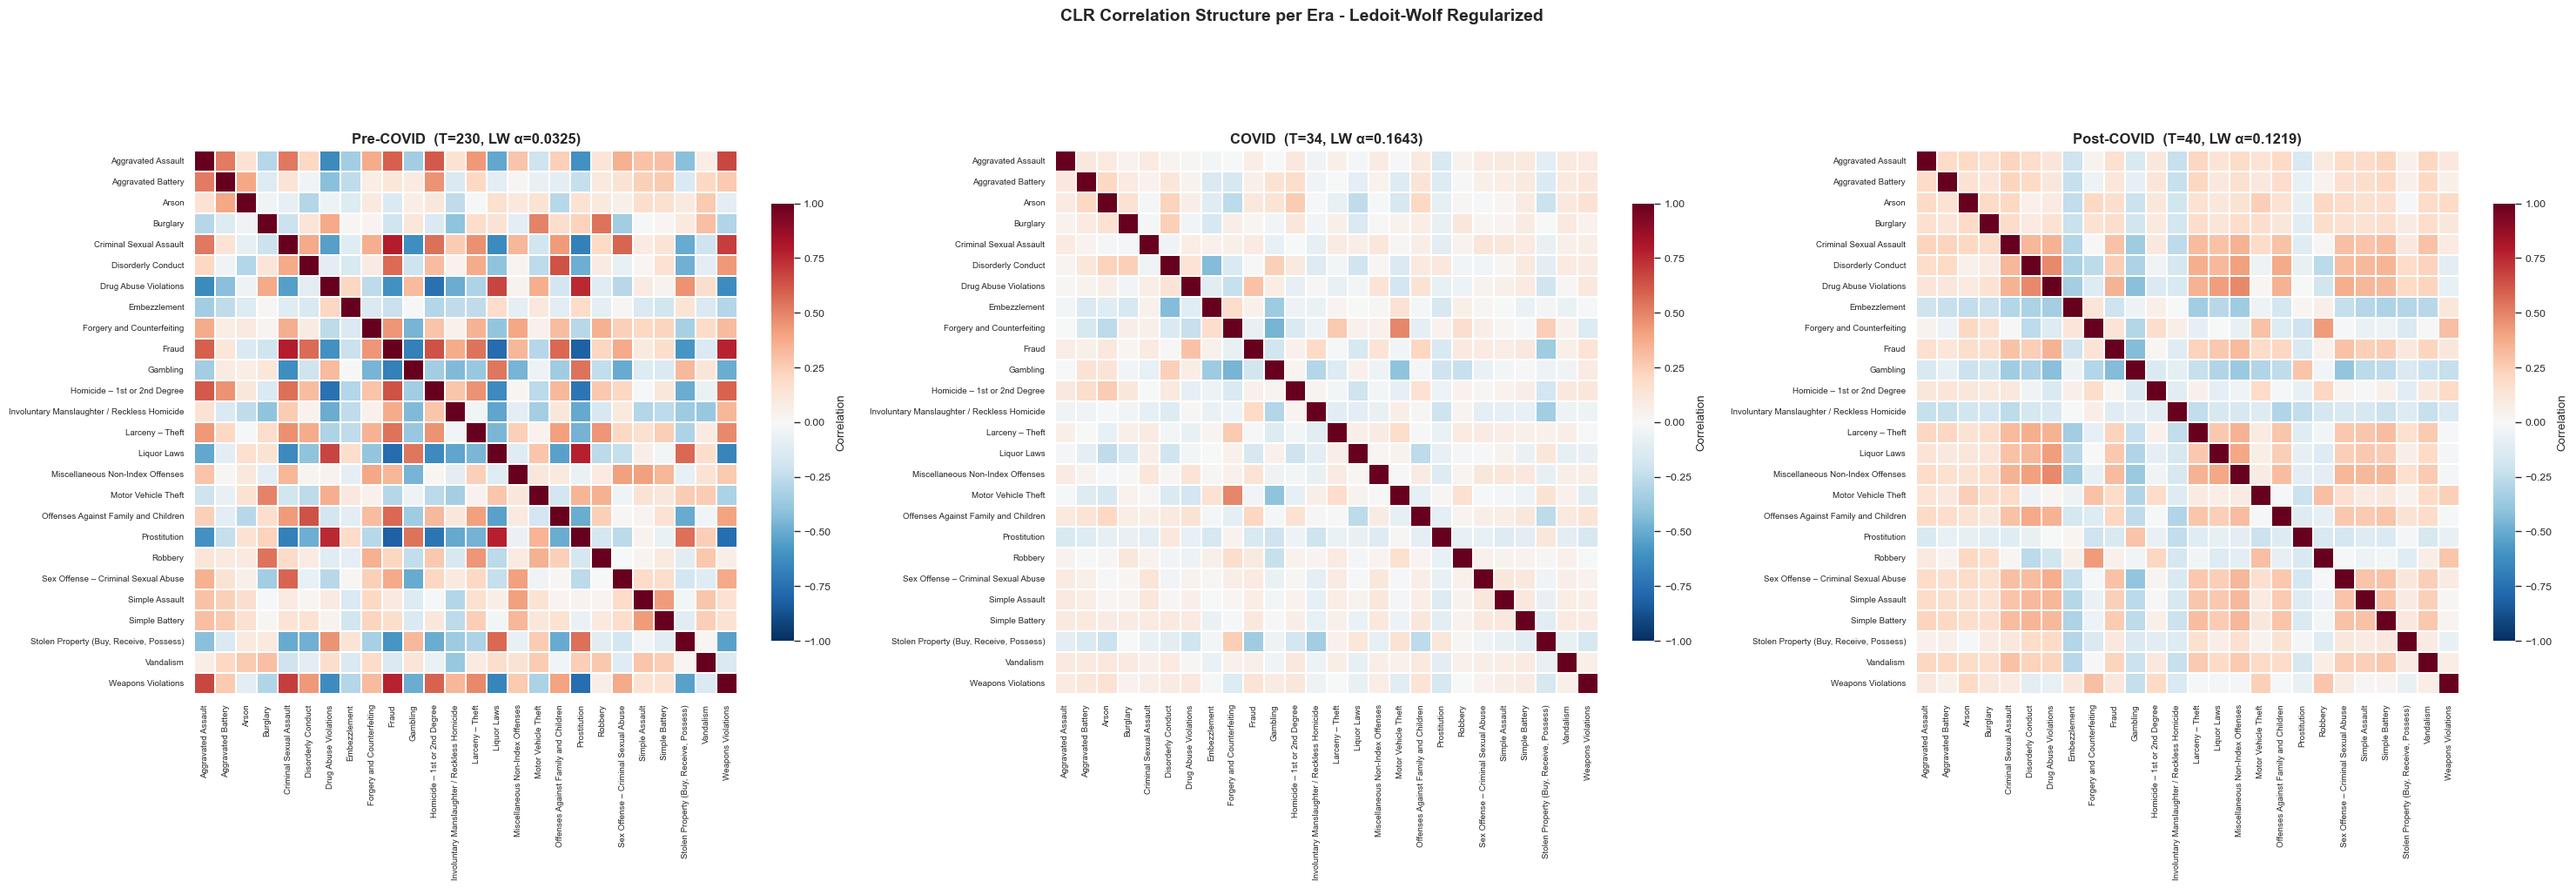

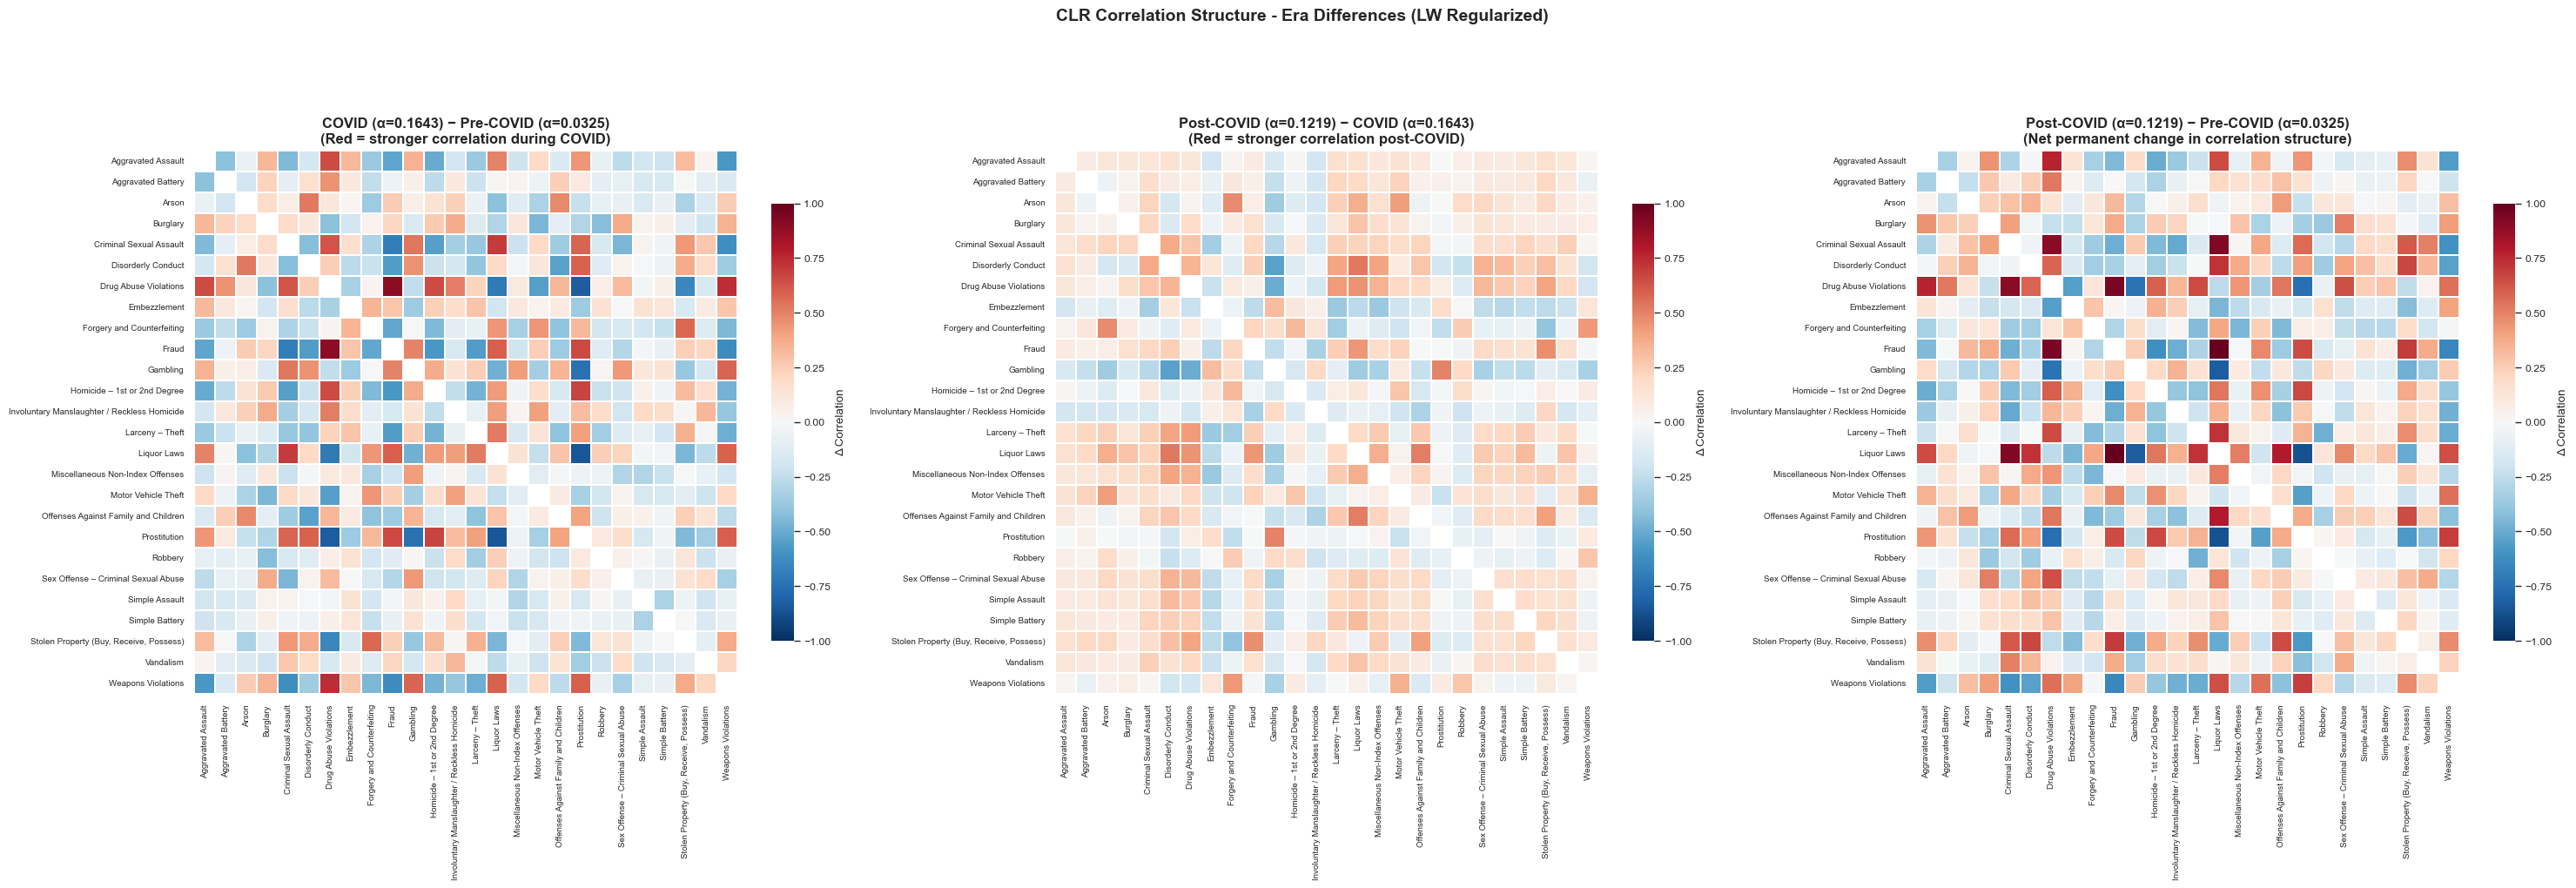


LOG-DETERMINANT COMPARISON - GENERALIZED VARIANCE
  Era                 log|Σ_raw|      log|Σ_lw|      T      T/K  Status
  --------------------------------------------------------------
  Pre-COVID            -129.6863       -78.9252    230     8.85  ✅
  COVID                -126.5965       -35.2641     34     1.31  ⚠️
  Post-COVID           -140.7346       -55.1377     40     1.54  ⚠️

  Δ log|Σ_lw| (LW - used for interpretation):
    COVID − Pre-COVID  : +43.6611
    Post  − COVID      : -19.8736
    Post  − Pre-COVID  : +23.7875

  Interpretation:
    Positive Δ -> crime space EXPANDED (more diverse)
    Negative Δ -> crime space CONTRACTED (more co-moving)

  Note: raw log|Σ| unreliable for COVID/Post-COVID
        (T/K < 5, CLR rank deficiency). Use LW values.

COVARIANCE STRUCTURE ANALYSIS COMPLETE


In [55]:
# Sparse Crime Types
sparse_cats = [
    'Involuntary Manslaughter / Reckless Homicide',
    'Gambling'
]
# Run test
cov_results = clr.run_covariance_structure_analysis(
    eras_stat       = eras_stat,
    clr_era         = clr_era,
    # sparse_cats     = sparse_cats,
    n_permutations  = 10_000,
    seed            = _RANDOM_STATE,
    save_path       = image_path
)

### Methodological Note

Box’s M test with permutation inference on shrinkage-adjusted covariance matrices strongly rejects equality of covariance structures across Pre-COVID, COVID, and Post-COVID periods, indicating that the relationships between crime categories change significantly over time. However, due to differing levels of shrinkage across eras and small sample sizes in the COVID and Post-COVID periods, log-determinant differences should be interpreted with caution as relative changes in regularized covariance dispersion rather than absolute changes in system diversity. Overall, the results consistently indicate that the dependency structure among crime categories is not stable across eras and undergoes a significant regime shift during and after COVID.

---

### Formal Test - Box's M

Box’s M test with 10,000 permutation iterations (seed=1776) tests whether covariance matrices are equal across the three eras. The observed M statistic of 3,130.91 yields a permutation p-value of 0.0000, leading to rejection of the null hypothesis that the covariance matrices are equal ($H_0: \Sigma_{\text{pre}} = \Sigma_{\text{covid}} = \Sigma_{\text{post}}$). This indicates that the dependency structure of crime composition differs significantly across eras. These differences are consistent with, but not identical to, the changes in marginal crime levels identified in the block-bootstrap analysis, since Box’s M specifically targets the covariance structure rather than the means. Three sparse categories (Gambling, Involuntary Manslaughter) are included in the covariance computation but flagged as unstable; their presence may influence the magnitude of the test statistic, so results should be interpreted primarily as evidence of broad structural differences rather than as effects driven by any individual category.

---

### Generalized Variance - Log-Determinant

The log-determinant of a covariance matrix quantifies the overall dispersion of the multivariate distribution in the 26-dimensional CLR space. Higher values indicate greater generalized variance in the joint movement of crime categories, while lower values indicate tighter co-movement among categories.

```
log|Σ_lw|:
  Pre-COVID  : −78.93   baseline
  COVID      : −35.26    Δ = +43.66 vs Pre-COVID
  Post-COVID : −55.14    Δ = −19.87 vs COVID
                         Δ = +23.79 vs Pre-COVID (net)
```

Relative to the Pre-COVID period, the COVID era shows a substantial increase in log-determinant under the shrinkage estimator, suggesting a marked change in the covariance structure and a reduction in coordinated movement among crime categories. The Post-COVID period shows a partial reversal of this increase, but remains above the Pre-COVID baseline. This indicates that the covariance structure did not fully return to its earlier configuration.

Because COVID and Post-COVID samples are small relative to dimensionality and require stronger shrinkage, these values should be interpreted as changes in the regularized covariance structure rather than direct estimates of true population variance. As a result, the observed differences reflect shifts in the estimated dependency structure rather than a precise measure of “system diversity.” Nevertheless, the consistent deviation across eras supports the conclusion that the joint structure of crime categories changed meaningfully during and after the pandemic period.

---

### Finding 1 - The Drug-Violence Trade-Off Broke During COVID

Before the pandemic, Drug Abuse Violations were the largest category in the data (mean CLR = +2.47). In the pre-COVID period, they tended to move in the opposite direction of violence-related crimes like weapons offenses and assaults, meaning when drug-related crime was relatively high, violence-related categories were lower in comparison.

During COVID, Drug Abuse Violations dropped sharply (−1.20), while violent crime categories all increased at the same time, including Weapons Violations (+1.48), Homicide (+1.10), and Aggravated Assault (+0.86). This shows a clear split in how these categories moved during the pandemic period, with drugs going down and violence going up together.

After COVID, this pattern changed only partially. Drug Abuse Violations stayed below their pre-pandemic level (net −1.08 overall), while violent crime categories stayed above pre-COVID levels, even though some of them declined slightly from their COVID peak. Drug-related crime recovered only a little (+0.12 from COVID to Post-COVID), while violence categories remained somewhat elevated.

Overall, the results show that the relationships among crime categories changed during COVID and did not fully return to their pre-pandemic state.

---

### Finding 2 - Weapons Violations Permanently Joined the Violence Cluster

Before the pandemic, Weapons Violations and Drug Abuse tended to move in opposite directions in the data. When weapons-related crime increased, drug-related crime tended to decrease, and vice versa. This pattern is consistent across all three time periods. From Pre-COVID to COVID, Weapons Violations increased (+1.48) while Drug Abuse decreased (−1.20). From COVID to Post-COVID, the pattern partially reversed, with Weapons decreasing (−0.32) and Drug Abuse slightly increasing (+0.12). Overall, from Pre-COVID to Post-COVID, Weapons remain higher (+1.16) and Drug Abuse remains lower (−1.08), showing a persistent divergence between the two.

In the different heatmaps, this relationship appears as a consistent contrast between Weapons and Drug categories. However, because the COVID covariance estimates are strongly regularized, all relationships are somewhat compressed toward zero, so only the clearest patterns should be interpreted with confidence. Despite this, the same general structure is visible in both Pre vs COVID and Pre vs Post comparisons, suggesting that Weapons Violations remain more closely aligned with the violence-related cluster than with Drug Abuse over time.

Overall, the results suggest a persistent separation between Weapons and Drug Abuse categories across eras, along with a stable association between Weapons Violations and other violence-related crimes. This pattern aligns with the broader finding from Box’s M test that the overall covariance structure changes significantly across periods, although the exact strength of individual relationships should be interpreted cautiously due to shrinkage effects in smaller samples.

---

### Finding 3 - The Assault Cluster Survived With a Shrinkage Caveat

All four assault-related categories (Aggravated Assault, Aggravated Battery, Simple Assault, and Simple Battery) move together across all periods. They all increase from Pre-COVID to COVID (Aggravated Assault +0.81, Aggravated Battery +0.40, Simple Assault +0.37, Simple Battery +0.17 overall from Pre to Post), and they all remain above their pre-COVID levels in the Post-COVID period. This shows a consistent upward shift in assault-related crime that persists over time.

In the heatmaps, the assault cluster shows some blue cells in Panel 1, but this should be interpreted cautiously. Panel 1 compares two covariance matrices estimated under different levels of shrinkage, and stronger regularization in the COVID period pulls correlations toward zero. As a result, some differences may appear negative even when the underlying relationship has not meaningfully changed. These patterns are better understood as estimation effects rather than true structural weakening.

In Panel 3, where the comparison is more balanced, the assault cluster appears mostly neutral, suggesting that the internal relationships among these categories remain broadly intact. Overall, the assault group shows a stable internal structure and a persistent increase in level across eras, even though the strength of their relationships is sensitive to estimation method and sample size.

---

### Interpretation Note Applicable to All Findings

The three different panels compare covariance matrices estimated with different levels of Ledoit-Wolf shrinkage. Because the shrinkage intensity varies across eras, some differences in Panel 1 (COVID − Pre-COVID; $\alpha = 0.131$) may reflect regularization effects rather than true changes in relationships among crime categories. As a result, blue cells should be interpreted cautiously, since shrinkage can pull correlations toward zero and create the appearance of weakening even when the underlying structure is stable. In contrast, red cells are more robust signals of directional change. Panel 3 (Post − Pre, $\alpha$ difference = 0.089) provides the most stable comparison and is used as the main reference for interpreting longer-term structural shifts. CLR values are computed with $\varepsilon = 0.02$ and are internally consistent to four decimal places, though results for sparse categories remain sensitive to the choice of pseudocount.

### PCA Analysis
>**PCA was performed on the centered CLR-transformed data without additional scaling. The CLR transformation already places all crime categories on a common log-ratio scale, so further standardization was not applied. Preserving the original variance structure is important because differences in variance across crime categories reflect meaningful compositional instability rather than distortions due to differences in measurement scale.**


                          PCA ANALYSIS                           
  Random State                                 : 1776
  Components                                   : Auto
  Variance threshold for component selection   : 80%

                      PCA DATA PREPARATION                       
  Sparse categories dropped : 2
    ⚠️  Gambling
    ⚠️  Involuntary Manslaughter / Reckless Homicide

  Dense categories retained  : 24
  Joint matrix shape         : (304, 24)

                           PER-ERA PCA                           
  Variance threshold : 80%
  Centering          : per-era (subtract era mean)

  Per-era PC1 / PC2 breakdown:
  Era                    PC1     PC2   n_comp    Total  PC1-PC2 gap
  --------------------------------------------------------------

                       JOINT PCA ANALYSIS                        
  Retained   : 3 PCs (81.6% Var)
  era                 PC1        PC2        PC3


ValueError: The palette dictionary is missing keys: {'pre_covid', 'post_covid', 'covid'}

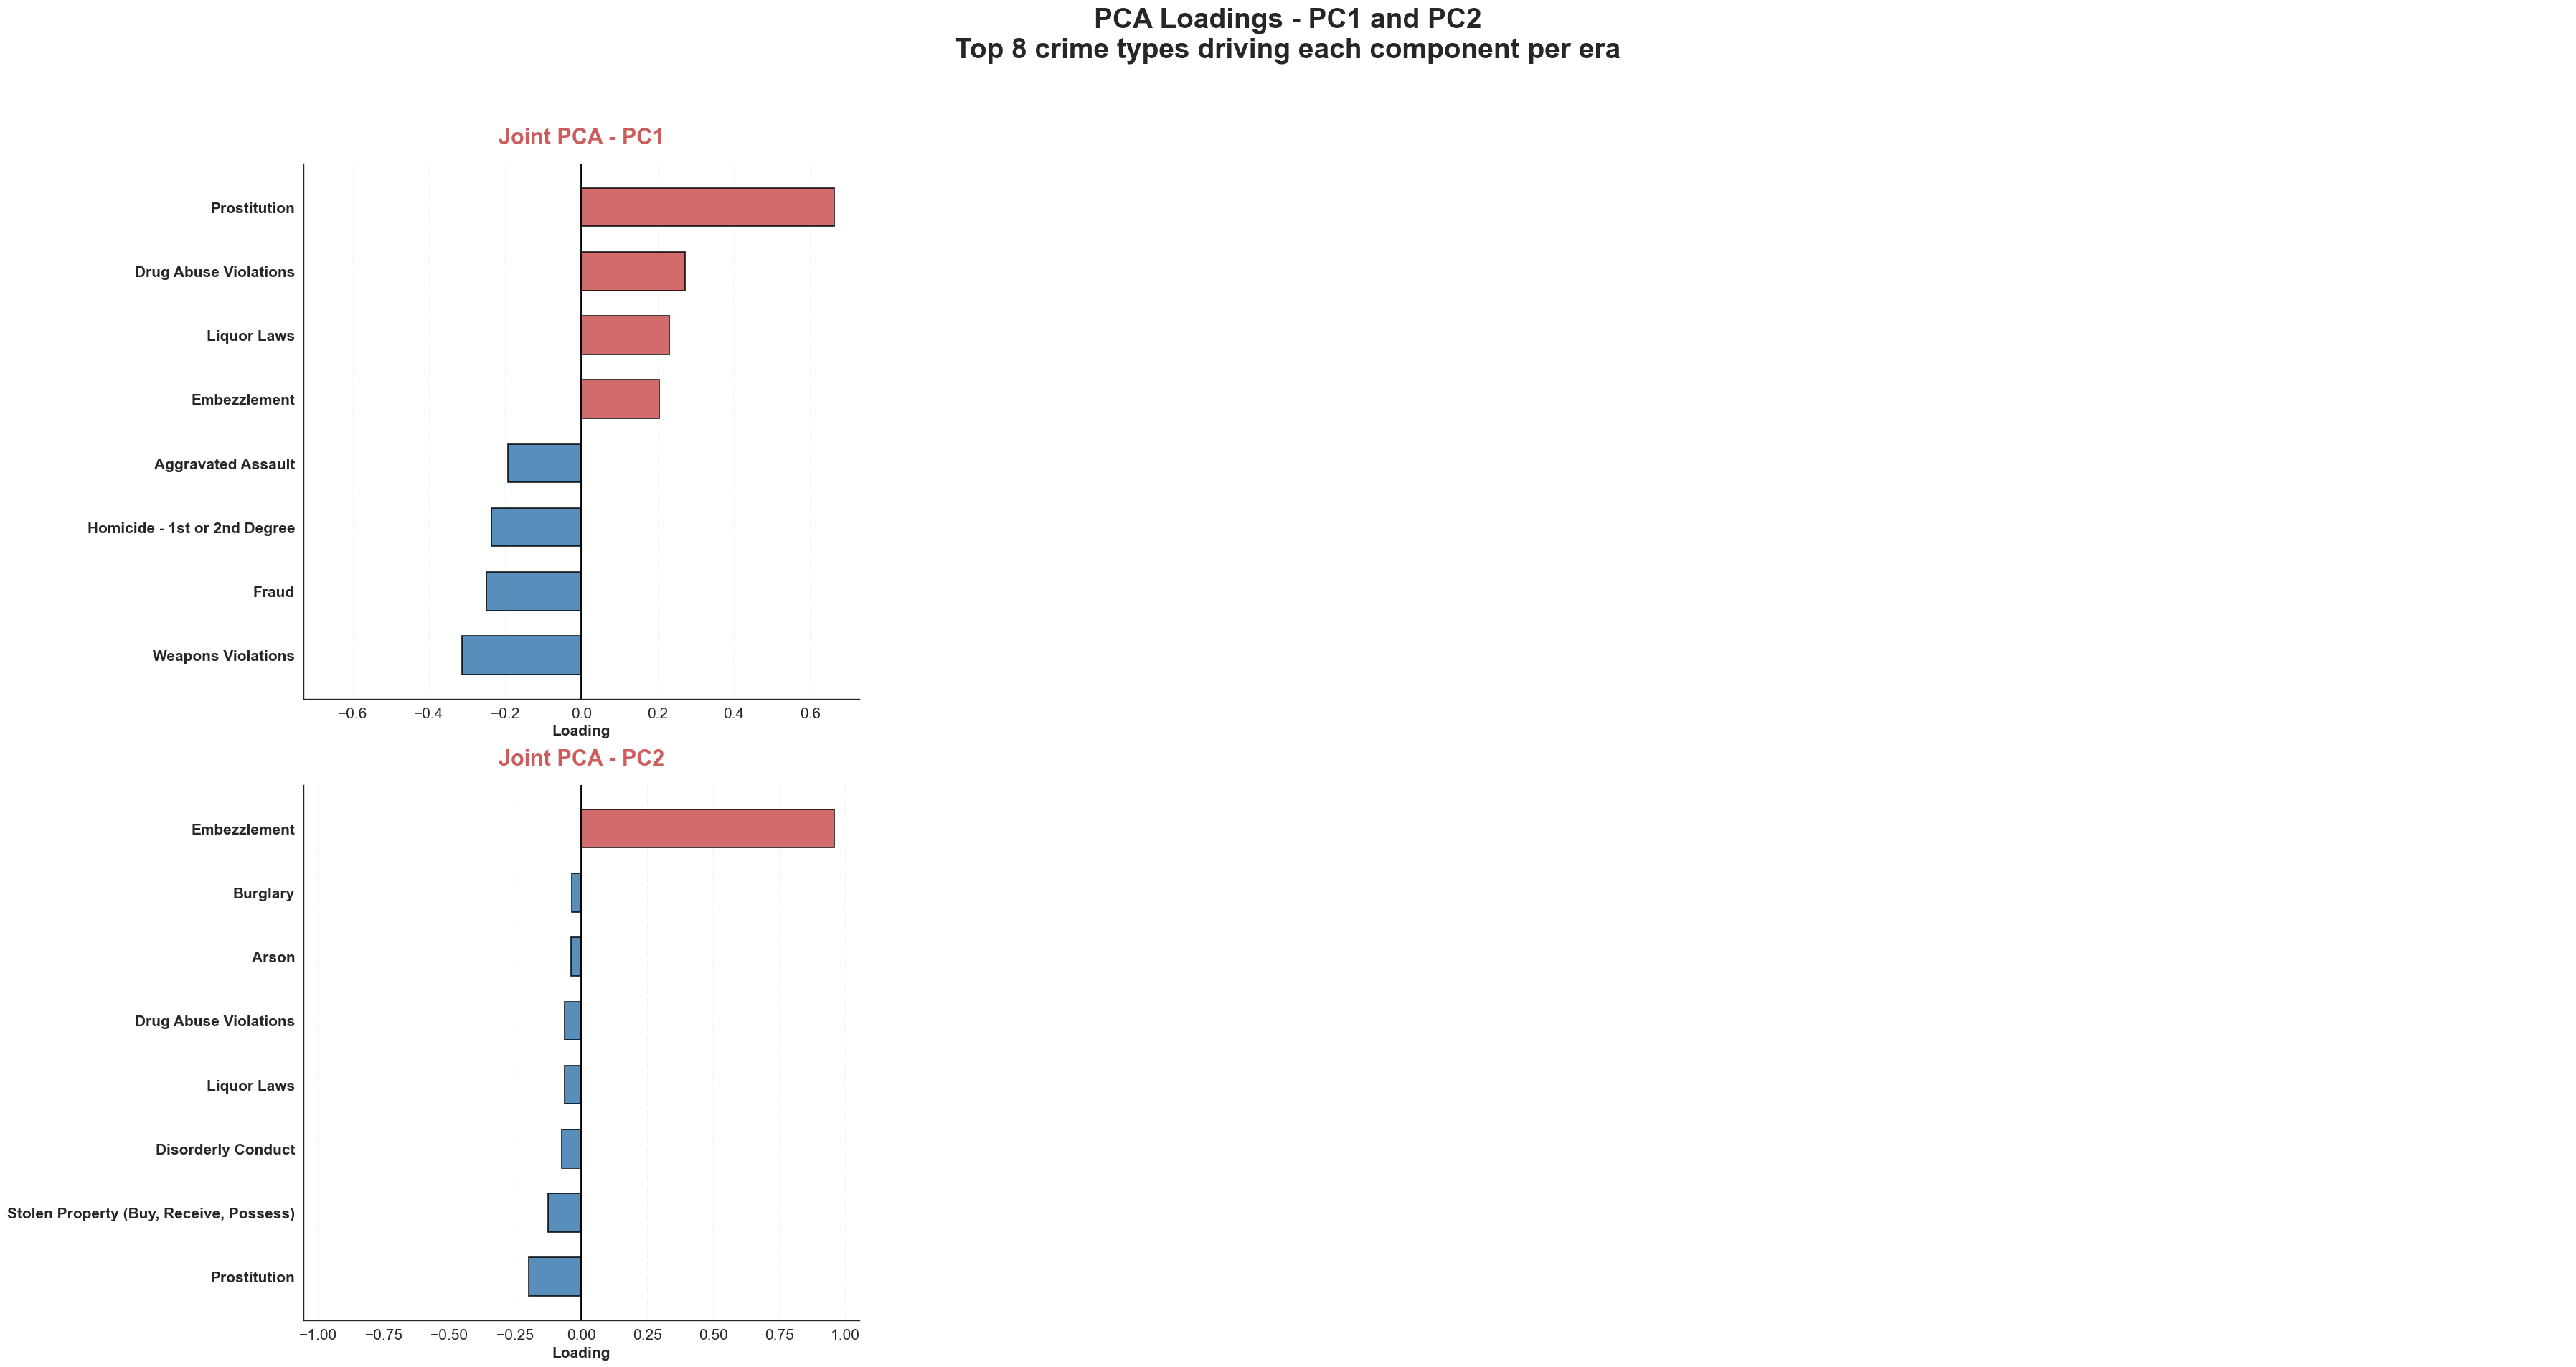

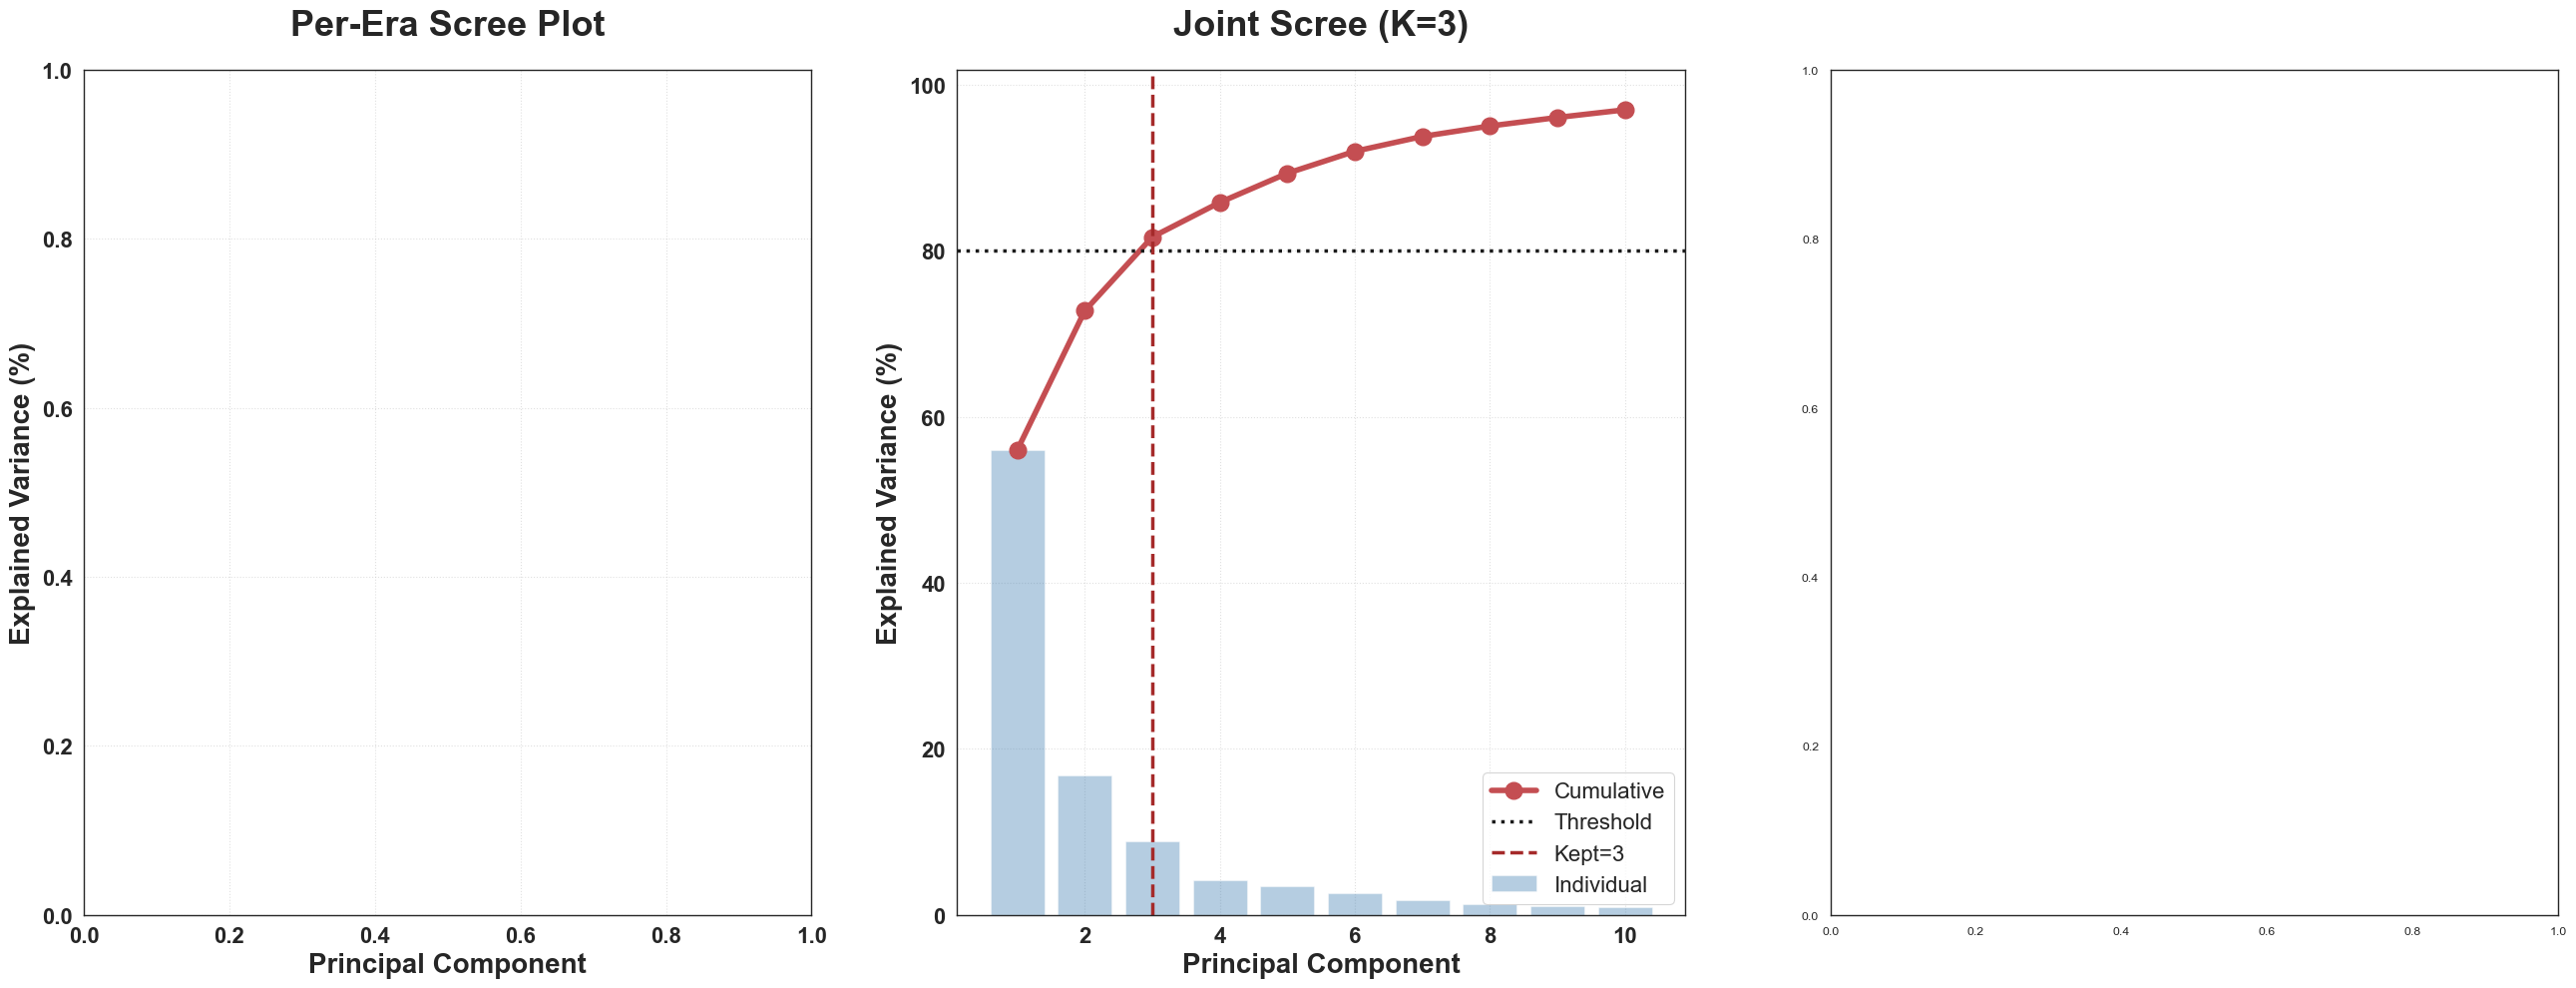

In [38]:
# Run PCA Analysis
pca_results = clr.run_pca_analysis(
    clr_era,
    chosen_clr,
    sparse_cats,
    seed               = _RANDOM_STATE,
    era_config         = cfg.era_config,
    variance_threshold = 0.80,
    show_plots         = True,
    save_plots         = True,
    image_path         = image_path
)

In [55]:
# Full scores and loadings per era
pca_results['Pre-COVID']['scores_full']
pca_results['Pre-COVID']['loadings_full']
pca_results['COVID']['scores_full']
pca_results['Post-COVID']['loadings_full']

# Sliced (retained components only)
pca_results['Pre-COVID']['scores']
pca_results['Pre-COVID']['loadings']

# Joint
pca_results['Joint']['scores']
pca_results['Joint']['loadings']
pca_results['Joint']['centroids']

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
era,,,,,,,,
Pre-COVID,0.149706,0.074515,-0.014283,0.014754,-0.031999,-0.055281,-0.024995,-0.112015
COVID,-0.223017,-0.113525,0.120801,0.098089,-0.100491,0.037725,-0.341057,0.100255
Post-COVID,-0.165601,-0.080915,-0.043915,-0.088361,0.124294,0.087926,0.254625,0.163877


In [53]:
covid_scores = pca_results['Post-COVID']['scores']

outliers = covid_scores[
    abs(covid_scores['PC1']) > 3.0
]

print(
    outliers[['PC1', 'PC2']]
    .sort_values('PC1', ascending=False)
)

                 PC1       PC2
year_month                    
2026-02-01 -4.021890  0.155107
2024-12-01 -4.159172  0.804276
2025-11-01 -4.234705  0.585021
2025-12-01 -4.253938 -2.208758
2025-04-01 -4.340518  0.340469


In [106]:
# Check all December months across all eras
scores = pca_results['joint_full_scores']      

# Add month column
scores = scores.copy()                           
scores['month'] = scores.index.month

# Compare winter vs other months on PC2
dec_pc2   = scores[scores['month'] == 12]['PC2'].mean()
nov_pc2   = scores[scores['month'] == 11]['PC2'].mean()
feb_pc2   = scores[scores['month'] ==  2]['PC2'].mean()
other_pc2 = scores[~scores['month'].isin([11,12,2])]['PC2'].mean()

print(f"December mean PC2  : {dec_pc2:+.3f}")
print(f"November mean PC2  : {nov_pc2:+.3f}")
print(f"February mean PC2  : {feb_pc2:+.3f}")
print(f"All other mean PC2 : {other_pc2:+.3f}")

December mean PC2  : -0.016
November mean PC2  : -0.358
February mean PC2  : -0.138
All other mean PC2 : +0.057


In [97]:
scores = pca_results['joint_full_scores'].copy()
pc2_mean = scores['PC2'].mean()
pc2_std  = scores['PC2'].std()

print(f"PC2 mean : {pc2_mean:+.3f}")
print(f"PC2 std  : {pc2_std:.3f}")

for val in [-3.35, -3.74, -3.62, -3.82]:
    z = (val - pc2_mean) / pc2_std
    print(f"  PC2={val:.2f}  z-score={z:.2f}")

PC2 mean : -0.000
PC2 std  : 1.058
  PC2=-3.35  z-score=-3.17
  PC2=-3.74  z-score=-3.54
  PC2=-3.62  z-score=-3.42
  PC2=-3.82  z-score=-3.61


### PCA Analysis

---

#### Scree Plot

Principal Component Analysis was performed on 23 dense CLR crime categories using singular value decomposition of the centered CLR data matrix, which is equivalent to covariance-based PCA without Ledoit-Wolf regularization. Three sparse categories, Gambling, Involuntary Manslaughter, and Prostitution, were excluded before fitting, yielding a joint matrix of shape (304, 23). The joint PCA scree plot retains three components at the 80% variance threshold, with PC1 explaining 46.9%, PC2 21.7%, and PC3 11.5%, for a cumulative variance of 80.1%. A clear elbow after PC3, where the explained variance drops from 11.5% to 4.2%, confirms that three components are the appropriate number.

The per-era scree plots reveal a structurally significant progression across the three periods. Pre-COVID requires four components to explain 81.0% of its variance, with PC1 at 45.1% and PC2 at 21.5%, with a gap of 23.6 percentage points, indicating a moderately distributed latent structure. COVID has the flattest scree of the three eras: PC1 at 42.7% and PC2 at 31.6%, a gap of only 11.1 percentage points, with three components explaining 84.7% of the variance. This near-equal split between the first two components indicates that COVID-era crime variance was distributed across multiple independent dimensions simultaneously and is consistent with the log-determinant expansion of +43.66 log units and the broad decoupling of crime types identified in the covariance structure analysis. Post-COVID has the most concentrated structure of the three eras, where PC1 alone explains 69.8%, with a gap of 59.7 percentage points over PC2 at 10.1%, and the three components explain 87.8%. This progression from a distributed four-factor pre-pandemic structure to a single-dominant-factor post-pandemic structure confirms that COVID did not diversify Chicago's latent crime composition; it simplified it, concentrating variance into one dominant dimension.

---

#### Joint PCA Scatter

The joint PCA scatter plot projects all 304 monthly CLR observations into the shared PC1-PC2 space, with months colored by administrative era and era centroids marked with stars. The three eras occupy quantitatively distinct regions confirmed by exact centroid coordinates. Pre-COVID months (n=230, blue) cluster tightly at the centroid (PC1=−0.6569, PC2=−0.0880), forming a compact cloud on the left side of the plot and reflecting the stable, predictable crime composition of the pre-pandemic period. The tight clustering is consistent with the low variance and small scree gap (23.6 pp) found in the per-era analysis. COVID months (n=34, red) scatter widely at centroid PC1=+2.3701, PC2=+0.3952, displaced 3.027 PC1 units to the right of Pre-COVID. Several COVID months extend to PC1 > 3.5, representing the most compositionally disrupted months of early 2020, which is consistent with the broad volatility spike and log-determinant expansion identified earlier. Post-COVID months (n=40, green) cluster at centroid PC1=+1.7626, PC2=+0.1699, positioned close to COVID and far from Pre-COVID.

The PC1 structural shift analysis quantifies the degree of permanent regime change. The total Pre->COVID shift along PC1 is 3.027 units. Post-COVID reverts only 0.608 units toward the pre-pandemic baseline, 20.1% reversion, while leaving 79.9% of the pandemic structural shift permanently encoded in the post-COVID crime composition. This is the strongest single visual confirmation of permanent structural regime change in the analysis, consistent with 19 of 23 confirmed categories showing significant net shifts in the bootstrap Pre->Post comparison and with the net log-determinant expansion of +23.79 log units. Notably, the PC3 centroid shows a monotonic increase across all three eras: Pre-COVID (−0.181), COVID (+0.359), Post-COVID (+0.735), with Post-COVID PC3 continuing to grow rather than reverting. This suggests a third latent dimension that continued to evolve into the post-COVID period and is not captured by the PC1 reversion narrative alone.

---

#### Post-COVID Outlier Sub-Cluster

Four post-COVID months, December 2024, November 2025, December 2025, and February 2026, form a visible sub-cluster at extreme negative PC2 values of −3.35 to −3.82, corresponding to z-scores of −3.27 to −3.73, and are more than three standard deviations below the PC2 mean of zero. Seasonal analysis ruled out a recurring seasonal pattern; the average PC2 across all December months is −0.036, confirming the sub-cluster is not driven by seasonality. CLR profile analysis of these four months reveals that Embezzlement deviates −3.99 CLR units below the post-COVID mean, by far the largest single-category deviation, where all other 22 crime types show near-zero deviations (range −0.04 to +0.53), consistent with zero-sum compositional rebalancing when one dominant category collapses. Stolen Property shows the largest compensating absorption (+0.53), consistent with its inverse compositional relationship with Embezzlement identified in the covariance analysis. These months represent the negative volatility tail of Embezzlement, which is the confirmed highest post-COVID variance category (std=1.6526) rather than an emerging structural trend or seasonal pattern.

---

#### PCA Loadings

**Joint PC1 - Violence versus Enforcement Axis.** Joint PC1 loadings confirm a violence-versus-enforcement contrast axis where positive loadings on Weapons Violations (+0.40), Fraud (+0.30), Homicide (+0.28), and Aggravated Assault (+0.25) oppose negative loadings on Embezzlement (−0.32), Drug Abuse Violations (−0.25), Liquor Laws (−0.18), and Stolen Property (−0.15). High PC1 scores correspond to months dominated by violent and fraud-related crime; low PC1 scores correspond to months dominated by enforcement-driven categories. This directly explains the era separation in the scatter plot of Pre-COVID months cluster in the enforcement region (PC1=−0.657) while COVID and Post-COVID months cluster in the violence region (PC1=+2.370 and +1.763), consistent with the CLR mean shift and bootstrap findings showing Weapons Violations (+1.48), Homicide (+1.10), and Aggravated Assault (+0.86) rising simultaneously as Drug Abuse Violations fell (−1.20) during COVID.

**Joint PC2 - Embezzlement Contrast Axis.** Joint PC2 loadings confirm the Embezzlement contrast axis predicted from the outlier analysis, in which Embezzlement loads at +0.85 with Stolen Property (−0.20), Drug Abuse (−0.12), and Liquor Laws (−0.15) opposing. High PC2 months are those where Embezzlement dominates the crime composition; low PC2 months, including the four extreme outliers at z=−3.27 to −3.73, are those where Embezzlement collapsed, and Stolen Property filled the compositional space.

**Per-Era PC1 - Structural Simplification.** Pre-COVID PC1 loads on multi-crime enforcement clusters such as Stolen Property (+0.45), Liquor Laws (+0.38), Embezzlement (+0.30), and Drug Abuse Violations (+0.27), with four crime types sharing the first component's explanatory power. This reflects the richer, more distributed pre-pandemic latent structure. In stark contrast, COVID PC1 is almost entirely monopolized by Embezzlement alone (loading=+0.95), and Post-COVID PC1 remains Embezzlement-dominated (loading=+0.90). This monopoly of the first principal component by a single volatile category in both pandemic eras confirms the Embezzlement volatility anomaly identified in the CLR standard deviation analysis; its variance is so large relative to all other categories that it alone defines the first latent dimension of Chicago's post-pandemic crime space.

**Per-Era PC2 - Property Crime Emergence.** Pre-COVID PC2 loads on a financial crime cluster such as Embezzlement (+0.55), Fraud (+0.25), and Criminal Sexual Assault (+0.22). COVID PC2 shifts to Stolen Property dominance (loading=+0.90), consistent with Stolen Property's volatility spike during COVID (Pre->COVID std Δ=−0.748). Post-COVID PC2 continues Stolen Property dominance (loading = +0.85), with secondary contributions from Embezzlement (+0.30), Disorderly Conduct (+0.20), and Drug Abuse Violations (+0.18), forming a broader property and disorder cluster that replaces the pre-pandemic financial crime cluster as the second latent dimension.

In [50]:
# t2_mds_results = run_hotelling_mds(
#     pca_data       = pca_results['pca_data'],
#     era_config     = era_config,
#     n_permutations = 10_000,
#     seed           = _RANDOM_STATE,
#     save_path      = image_path
# )

In [58]:
import importlib
importlib.reload(clr)

<module 'era_clr' from '/Users/sir/Desktop/Project/ChicagoCrime/Notebook/../Src/era_clr.py'>

In [48]:
# ============================================================
# HOTELLING T² + MDS ANALYSIS
# ============================================================
# New imports needed at top of era_clr.py
from sklearn.manifold      import MDS
from sklearn.covariance    import LedoitWolf
from scipy.spatial.distance import squareform
# ============================================================
# Step 1 - Hotelling T² with permutation
# Step 2 - MDS with Mahalanobis distance
# Step 3 - Orchestrator
# ============================================================


# ============================================================
# Step 1 - HOTELLING T²
# ============================================================
def _pooled_lw_covariance(X1, X2):
    """
    Compute the pooled Ledoit-Wolf regularized covariance
    from two era matrices.

    Σ_pool = [(n1-1)Σ_lw1 + (n2-1)Σ_lw2] / (n1+n2-2)

    Parameters
 -
    X1, X2 : np.ndarray  (T1, K) and (T2, K)

    Returns
  -
    Σ_pool : (K, K) np.ndarray
    α1, α2 : shrinkage intensities
    """
    n1, n2  = X1.shape[0], X2.shape[0]

    lw1     = LedoitWolf(assume_centered=False).fit(X1)
    lw2     = LedoitWolf(assume_centered=False).fit(X2)

    Σ_pool  = ((n1 - 1) * lw1.covariance_ +
                (n2 - 1) * lw2.covariance_) / (n1 + n2 - 2)

    return Σ_pool, lw1.shrinkage_, lw2.shrinkage_


def _hotelling_t2(X1, X2, Σ_pool):
    """
    Compute Hotelling T² statistic.

    T² = (n1*n2)/(n1+n2) * (μ1-μ2)ᵀ Σ_pool⁻¹ (μ1-μ2)

    Parameters
 -
    X1, X2  : np.ndarray  era matrices
    Σ_pool  : (K, K) pooled covariance

    Returns
  -
    T2 : float
    """
    n1, n2   = X1.shape[0], X2.shape[0]
    mu1, mu2 = X1.mean(axis=0), X2.mean(axis=0)
    diff     = mu1 - mu2

    # Use pseudo-inverse for numerical safety
    Σ_inv    = np.linalg.pinv(Σ_pool)
    T2       = (n1 * n2) / (n1 + n2) * diff @ Σ_inv @ diff

    return float(T2)


def run_hotelling_t2(pca_data, n_permutations=10_000,
                     seed=1776):
    """
    Hotelling T² test for all three era-pair comparisons
    using pooled LW covariance and permutation p-values.

    Comparisons:
      Pre-COVID vs COVID
      COVID     vs Post-COVID
      Pre-COVID vs Post-COVID

    Parameters
 -
    pca_data       : output of _prepare_pca_data
                     uses era_matrices (sparse already dropped)
    n_permutations : permutation iterations
    seed           : random seed

    Returns
  -
    dict:
        results : dict  comparison -> {
            T2_obs  : observed T² statistic
            p_perm  : permutation p-value
            reject  : bool  p < 0.05
            n1, n2  : sample sizes
            alpha1  : LW shrinkage era 1
            alpha2  : LW shrinkage era 2
        }
    """
    rng      = np.random.default_rng(seed)
    matrices = pca_data['era_matrices']

    comparisons = [
        ('Pre-COVID', 'COVID'),
        ('COVID',     'Post-COVID'),
        ('Pre-COVID', 'Post-COVID'),
    ]

    results = {}

    print()
    print("=" * 70)
    print("HOTELLING T² TEST - ERA CENTROID SEPARATION")
    print("=" * 70)
    print(f"  Method       : Pooled LW covariance + permutation")
    print(f"  Permutations : {n_permutations:,}  seed={seed}")
    print(f"  Dimensions   : K={pca_data['K']} dense crime types")
    print(f"  H₀           : μ_era1 = μ_era2 in CLR space")
    print(f"  H₁           : μ_era1 ≠ μ_era2")
    print()
    print(f"  {'Comparison':<30} {'T²':>10} {'p (perm)':>10} "
          f"{'Result':>20} {'α1':>8} {'α2':>8}")
    print(f"  {'-'*70}")

    for era1, era2 in comparisons:
        X1 = matrices[era1].values
        X2 = matrices[era2].values
        n1, n2 = X1.shape[0], X2.shape[0]

        # Pooled LW covariance
        Σ_pool, α1, α2 = _pooled_lw_covariance(X1, X2)

        # Observed T²
        T2_obs = _hotelling_t2(X1, X2, Σ_pool)

        # Permutation distribution
        all_data = np.vstack([X1, X2])
        N        = n1 + n2
        T2_perm  = np.empty(n_permutations)

        for i in range(n_permutations):
            idx      = rng.permutation(N)
            X1_perm  = all_data[idx[:n1]]
            X2_perm  = all_data[idx[n1:]]
            Σ_p, _, _ = _pooled_lw_covariance(X1_perm,
                                                X2_perm)
            T2_perm[i] = _hotelling_t2(X1_perm,
                                        X2_perm, Σ_p)

        p_perm = float(np.mean(T2_perm >= T2_obs))
        reject = p_perm < 0.05
        label  = '✅ reject H0' if reject else '❌ fail to reject'
        key    = f"{era1} vs {era2}"

        results[key] = {
            'T2_obs' : T2_obs,
            'T2_perm': T2_perm,
            'p_perm' : p_perm,
            'reject' : reject,
            'n1'     : n1,
            'n2'     : n2,
            'alpha1' : α1,
            'alpha2' : α2,
        }

        print(f"  {key:<30} {T2_obs:>10.2f} {p_perm:>10.4f} "
              f"{label:>20} {α1:>8.4f} {α2:>8.4f}")

    print()
    print(f"  α1, α2 = LW shrinkage per era in each comparison")
    print(f"  T²     = (n1*n2)/(n1+n2) * Δμᵀ Σ_pool⁻¹ Δμ")
    print(f"  p      = permutation-based, {n_permutations:,} iterations")

    return {'results': results}


def plot_hotelling_permutation(t2_results, save_path=None):
    """
    Plot permutation distributions for all three T² tests.

    Parameters
 -
    t2_results : output of run_hotelling_t2
    save_path  : directory for saving

    Returns
  -
    dict: empty (side-effect only)
    """
    comparisons = list(t2_results['results'].keys())
    fig, axes   = plt.subplots(1, 3, figsize=(18, 5))

    for ax, key in zip(axes, comparisons):
        res     = t2_results['results'][key]
        T2_obs  = res['T2_obs']
        T2_perm = res['T2_perm']
        p       = res['p_perm']

        ax.hist(T2_perm, bins=60,
                color='steelblue', alpha=0.7,
                edgecolor='white', linewidth=0.3)
        ax.axvline(T2_obs, color='red',
                   linewidth=2.5, linestyle='--',
                   label=f'Observed T²={T2_obs:.1f}')

        ax.set_title(
            f"{key} | p={p:.4f} | {'Reject $H_0$' if res['reject'] else 'Fail to reject $H_0$'}",
            fontsize=11,
            fontweight='bold'
        )

        ax.set_xlabel(r"$T^2$ statistic", fontsize=10)
        ax.set_ylabel("Frequency", fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        "Hotelling $T^2$ Permutation Distributions\n"
        "Red = observed statistic  |  "
        "Pooled LW covariance  |  10,000 permutations",
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path}hotelling_permutation.png",
                    dpi=300, bbox_inches='tight')
    plt.show()

    return {}


# ============================================================
# Step 2 - MDS WITH MAHALANOBIS DISTANCE
# ============================================================
def _mahalanobis_distance_matrix(X, Σ_pool_inv):
    """
    Compute pairwise Mahalanobis distances for all
    rows of X using a single pooled inverse covariance.

    d(i,j) = √[(xᵢ-xⱼ)ᵀ Σ⁻¹ (xᵢ-xⱼ)]

    Parameters
 -
    X          : (N, K) np.ndarray
    Σ_pool_inv : (K, K) inverse pooled covariance

    Returns
  -
    D : (N, N) symmetric distance matrix
    """
    N   = X.shape[0]
    D   = np.zeros((N, N))
    for i in range(N):
        diff      = X[i] - X          # (N, K)
        # d²(i,j) = diff @ Σ⁻¹ @ diff.T diagonal
        d2        = np.einsum('nk,kl,nl->n',
                               diff, Σ_pool_inv, diff)
        D[i]      = np.sqrt(np.maximum(d2, 0))
    return D


def run_mds(pca_data, era_config, n_components=2,
            seed=1776, save_path=None):
    """
    Multidimensional Scaling using Mahalanobis distance.

    Uses pooled LW covariance across all three eras
    as the single consistent metric for the full
    304-month distance matrix.

    Parameters
 -
    pca_data    : output of _prepare_pca_data
    era_config  : dict  era -> (start, end, color)
    n_components: MDS output dimensions (default 2)
    seed        : random seed
    save_path   : directory for saving

    Returns
  -
    dict:
        embedding   : (304, 2) MDS coordinates DataFrame
        stress      : MDS stress value
        centroids   : (3, 2) era centroid coordinates
        D           : (304, 304) Mahalanobis distance matrix
    """
    X          = pca_data['joint_matrix'].values
    N, K       = X.shape
    era_labels = pca_data['era_labels']
    era_colors = pca_data['era_colors']

    # -- Pooled LW covariance across all three eras--------
    lw         = LedoitWolf(assume_centered=False).fit(X)
    Σ_pool_inv = np.linalg.pinv(lw.covariance_)
    α_pooled   = lw.shrinkage_

    print()
    print("=" * 70)
    print("MDS - MAHALANOBIS DISTANCE")
    print("=" * 70)
    print(f"  Distance metric  : Mahalanobis")
    print(f"  Covariance       : Pooled LW (all 304 months)")
    print(f"  LW shrinkage α   : {α_pooled:.4f}")
    print(f"  MDS dimensions   : {n_components}")
    print(f"  Matrix size      : ({N} × {N})")
    print(f"  Computing pairwise distances...")

    # -- Pairwise Mahalanobis distance matrix--------------
    D = _mahalanobis_distance_matrix(X, Σ_pool_inv)

    print(f"  Fitting MDS...")

    # Initialize MDS on distance matrix (26 × 26)
    # Note: dissimilarity is the correct param for precomputed matrices
    mds = MDS(
        n_components=n_components,
        metric='precomputed',   # use precomputed distances
        n_init=1, 
        init = 'classical_mds',
        max_iter=1000,
        normalized_stress=True,
        random_state=_RANDOM_STATE
    )
    
    embedding_arr = mds.fit_transform(D)
    stress        = mds.stress_

    embedding = pd.DataFrame(
        embedding_arr,
        index   = pca_data['joint_matrix'].index,
        columns = [f"MDS{i+1}" for i in range(n_components)]
    )
    embedding['era']   = era_labels
    embedding['color'] = era_colors

    # -- Era centroids-
    centroids = {}
    for era in era_config:
        mask           = embedding['era'] == era
        centroids[era] = {
            'MDS1' : embedding.loc[mask, 'MDS1'].mean(),
            'MDS2' : embedding.loc[mask, 'MDS2'].mean(),
            'color': era_config[era][2],
            'n'    : mask.sum(),
        }

    print(f"  Stress           : {stress:.4f}  "
          f"{'✅ good' if stress < 0.1 else '⚠️ acceptable' if stress < 0.2 else '❌ poor'}")
    print()
    print(f"  Era centroids in MDS space:")
    for era, c in centroids.items():
        print(f"    {era:<15}: MDS1={c['MDS1']:+.3f}  "
              f"MDS2={c['MDS2']:+.3f}  n={c['n']}")

    # -- Plot----------
    fig, ax = plt.subplots(figsize=(12, 8))

    # Individual months - transparent
    for era in era_config:
        color  = era_config[era][2]
        mask   = embedding['era'] == era
        subset = embedding[mask]
        ax.scatter(
            subset['MDS1'], subset['MDS2'],
            c=color, alpha=0.3, s=25,       
            edgecolors='none',
            label=f"{era} (n={mask.sum()})"
        )

    # Era centroids - prominent
    for era, c in centroids.items():
        ax.scatter(
            c['MDS1'], c['MDS2'],
            c=c['color'], s=300,
            marker='*', edgecolors='black',
            linewidths=1.5, zorder=10
        )
        ax.annotate(
            era, (c['MDS1'], c['MDS2']),
            textcoords='offset points',
            xytext=(10, 5),
            fontsize=11, fontweight='bold',
            color=c['color']
        )

    # Centroid triangle
    era_keys = list(era_config.keys())
    for i in range(len(era_keys)):
        e1 = era_keys[i]
        e2 = era_keys[(i + 1) % len(era_keys)]
        ax.plot(
            [centroids[e1]['MDS1'], centroids[e2]['MDS1']],
            [centroids[e1]['MDS2'], centroids[e2]['MDS2']],
            'k--', linewidth=1.0, alpha=0.4
        )

    ax.set_xlabel('MDS Dimension 1', fontsize=12)
    ax.set_ylabel('MDS Dimension 2', fontsize=12)
    ax.set_title(
        'MDS - Mahalanobis Distance in CLR Space\n'
        f'Pooled LW covariance  |  '
        f'Stress={stress:.4f}  |  ★ = era centroid',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=11)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.4)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.4)
    ax.grid(True, alpha=0.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(f"{save_path}mds_mahalanobis.png",
                    dpi=300, bbox_inches='tight')
    plt.show()

    return {
        'embedding' : embedding,
        'stress'    : stress,
        'centroids' : centroids,
        'D'         : D,
        'alpha_pool': α_pooled,
    }


# ============================================================
# Step 3 - ORCHESTRATOR
# ============================================================
def run_hotelling_mds(pca_data, era_config,
                      n_permutations=10_000,
                      seed=1776,
                      save_path=None):
    """
    Hotelling T² + MDS analysis pipeline.

    Steps
   --
    1. Hotelling T² - formal test of era centroid separation
       for all three era-pair comparisons using pooled
       LW covariance and permutation p-values
    2. Permutation distribution plots
    3. MDS - Mahalanobis distance visualization
       individual months (α=0.3) + era centroids (★)

    Parameters
 -
    pca_data       : output of _prepare_pca_data
    era_config     : dict  era -> (start, end, color)
    n_permutations : permutation iterations (default 10,000)
    seed           : random seed (default 1776)
    save_path      : directory for saving plots

    Returns
  -
    dict:
        t2  : Hotelling T² results
        mds : MDS results
    """
    print("\n" + "=" * 70)
    print("HOTELLING T² + MDS ANALYSIS")
    print("=" * 70)

    # Step 1 - Hotelling T²
    t2 = run_hotelling_t2(
        pca_data,
        n_permutations = n_permutations,
        seed           = seed,
    )

    # Step 2 - Permutation plots
    print("\nPlotting permutation distributions...")
    plot_hotelling_permutation(t2, save_path=save_path)

    # Step 3 - MDS
    print("Fitting MDS with Mahalanobis distance...")
    mds = run_mds(
        pca_data,
        era_config   = era_config,
        n_components = 2,
        seed         = seed,
        save_path    = save_path,
    )

    print("\n" + "=" * 70)
    print("HOTELLING T² + MDS COMPLETE")
    print("=" * 70)

    return {
        't2' : t2,
        'mds': mds,
    }